# St. Paul Full-Bill LVT Shift — HF 1342

**HF 1342** (and its identical senate companion) authorizes Minnesota cities to create **land-value taxation districts** that reallocate the **entire property tax bill** — city, county, school, areawide, state general levy — among parcels based on land value.

### How it works (Section 4)

The city designates a district. Within that district, **every jurisdiction's levy is still collected in full** — the total tax base doesn't change. But the *allocation among parcels* is shifted: land value carries a higher share, improvements carry a lower share.

### Key difference from city-only analysis (st_paul_v2)

| | st_paul_v2 | This notebook |
|---|---|---|
| Revenue base | City levy (~36% of bill) | **Full tax bill (all jurisdictions)** |
| `current_tax` | `TotalTax1 × 0.3572` | **`TotalTax1`** |
| Modeling approach | TC split-rate, 4:1 | TC split-rate, 4:1 |

Because the full bill is ~2.8× the city portion, the **absolute dollar shifts are larger** and the incentive effect is stronger — the rate advantage per dollar of new improvement is larger under the full-bill model.

In [365]:
# Step 1: Load parcel data
import sys
import pandas as pd
import geopandas as gpd
import numpy as np
import os
from datetime import datetime

sys.path.append('..')

from lvt_utils import (
    ensure_geodataframe, model_split_rate_tax,
    calculate_category_tax_summary, print_category_tax_summary
)
from policy_analysis import (
    analyze_vacant_land, analyze_land_by_improvement_share
)
from census_utils import (
    get_census_data_with_boundaries, match_to_census_blockgroups,
    calculate_median_percentage_by_quintile
)

pd.set_option('display.max_columns', None)

save_dir = os.path.join('data', 'st_paul')

# Find most recent geoparquet
files = [f for f in os.listdir(save_dir) if f.startswith('ramsey_county_') and f.endswith('.gpq')]
files_with_dates = []
for fname in files:
    try:
        date_str = fname.replace('ramsey_county_', '').replace('.gpq', '')
        dt = datetime.strptime(date_str, '%Y%m%d')
        files_with_dates.append((dt, fname))
    except Exception:
        continue

latest_fname = max(files_with_dates, key=lambda x: x[0])[1]
fpath = os.path.join(save_dir, latest_fname)
print(f'Loading: {fpath}')
ramsey_county_gdf = gpd.read_parquet(fpath)
print(f'Loaded {len(ramsey_county_gdf):,} parcels')

Loading: data/st_paul/ramsey_county_20260205.gpq
Loaded 167,677 parcels


## Step 2: Validate Against Official Tax Base

In [366]:
# Load official tax data from MN Dept of Revenue
# Download: https://www.revenue.state.mn.us/property-tax-history-data

excel_path = os.path.join('data', 'st_paul', 'data-portal-excel.xlsx')
city_town_df = pd.read_excel(excel_path, sheet_name='CityTown', header=0)

st_paul_official = city_town_df[
    (city_town_df.iloc[:, 5] == 'ST PAUL CITY OF') & 
    (city_town_df.iloc[:, 1] == 2025)
].iloc[0]

official_data = {
    'Estimated Market Value Total': st_paul_official['Estimated Market Value Total'],
    'Taxable Market Value Total': st_paul_official['Taxable Market Value Total'],
    'Local NTC Total (Tax Capacity)': st_paul_official['Local NTC by Class Total'],
    'TIF NTC': st_paul_official['TIF NTC'],
    'Fiscal Disparities NTC': st_paul_official['Fiscal Disparities Cont NTC'],
    'Taxable NTC': st_paul_official['Taxable NTC'],
    'Net Tax Total': st_paul_official['Net Tax Total'],
    'Total Avg Local NTC Tax Rate': st_paul_official['Total Avg Local NTC Tax Rate'],
    'City/Town Avg Tax Rate': st_paul_official['City/Town Avg Local NTC Tax Rate'],
    'TIF Levy': st_paul_official['TIF Levy'],
}

print('OFFICIAL ST. PAUL 2025 TAX DATA (MN Dept of Revenue)')
for key, val in official_data.items():
    if isinstance(val, float) and val < 10:
        print(f'{key}: {val:.4f}')
    else:
        print(f'{key}: ${val:,.0f}')

# Full combined NTC tax rate (city + county + school + special districts)
OFFICIAL_TOTAL_NTC_RATE = official_data['Total Avg Local NTC Tax Rate']
OFFICIAL_CITY_TAX_RATE = official_data['City/Town Avg Tax Rate']
OFFICIAL_TAXABLE_NTC = official_data['Taxable NTC']
OFFICIAL_TIF_NTC = official_data['TIF NTC']
OFFICIAL_LOCAL_NTC = official_data['Local NTC Total (Tax Capacity)']
OFFICIAL_NET_TAX = official_data['Net Tax Total']

print(f"\nFull combined NTC rate: {OFFICIAL_TOTAL_NTC_RATE:.4f}")
print(f"City-only NTC rate:    {OFFICIAL_CITY_TAX_RATE:.4f}")
print(f"City share of NTC rate: {OFFICIAL_CITY_TAX_RATE / OFFICIAL_TOTAL_NTC_RATE * 100:.1f}%")

OFFICIAL ST. PAUL 2025 TAX DATA (MN Dept of Revenue)
Estimated Market Value Total: $35,832,893,273
Taxable Market Value Total: $34,673,452,267
Local NTC Total (Tax Capacity): $409,200,716
TIF NTC: $28,684,858
Fiscal Disparities NTC: $38,513,418
Taxable NTC: $342,002,440
Net Tax Total: $674,665,907
Total Avg Local NTC Tax Rate: 1.4406
City/Town Avg Tax Rate: 0.5270
TIF Levy: $41,313,536

Full combined NTC rate: 1.4406
City-only NTC rate:    0.5270
City share of NTC rate: 36.6%


## Step 3: Filter to St. Paul City-Taxable Parcels

Under HF 1342, the full tax bill is reallocated. We use `TotalTax1` as the current tax for each parcel.

In [367]:
# Filter to St. Paul parcels
st_paul_gdf = ramsey_county_gdf[ramsey_county_gdf['SiteCityName'] == 'SAINT PAUL'].copy()
print(f'Total St. Paul parcels: {len(st_paul_gdf):,}')

# Flag TIF and exempt parcels
st_paul_gdf['in_tif'] = (
    st_paul_gdf['TIFDistrict'].notna() & 
    (st_paul_gdf['TIFDistrict'].str.strip() != '') &
    (st_paul_gdf['TIFDistrict'] != 'None')
)
st_paul_gdf['fully_exempt'] = (st_paul_gdf['TaxExemptYN'] == 'Y')
st_paul_gdf['pays_city_tax'] = (
    ~st_paul_gdf['in_tif'] & 
    ~st_paul_gdf['fully_exempt'] &
    st_paul_gdf['TaxCapacity'].notna() &
    (st_paul_gdf['TaxCapacity'] > 0)
)

print(f'  In TIF districts:   {st_paul_gdf["in_tif"].sum():,}')
print(f'  Fully tax exempt:   {st_paul_gdf["fully_exempt"].sum():,}')
print(f'  City-taxable:       {st_paul_gdf["pays_city_tax"].sum():,}')

Total St. Paul parcels: 83,399
  In TIF districts:   2,706
  Fully tax exempt:   3,408
  City-taxable:       77,100


In [368]:
# Validate scraped data against official tax base
scraped_total_ntc = st_paul_gdf['TaxCapacity'].sum()
scraped_tif_ntc = st_paul_gdf[st_paul_gdf['in_tif']]['TaxCapacity'].sum()
scraped_city_taxable_ntc = st_paul_gdf[st_paul_gdf['pays_city_tax']]['TaxCapacity'].sum()
scraped_total_emv = st_paul_gdf['EMVTotal1'].sum()

print('VALIDATION: SCRAPED vs OFFICIAL')
print(f"{'Metric':<30} {'Scraped':>18} {'Official':>18} {'Diff %':>10}")
print('-' * 80)

diff_pct = (scraped_total_ntc - OFFICIAL_LOCAL_NTC) / OFFICIAL_LOCAL_NTC * 100
print(f"{'Total Tax Capacity':<30} ${scraped_total_ntc:>15,.0f} ${OFFICIAL_LOCAL_NTC:>15,.0f} {diff_pct:>9.1f}%")

diff_pct = (scraped_tif_ntc - OFFICIAL_TIF_NTC) / OFFICIAL_TIF_NTC * 100
print(f"{'TIF Tax Capacity':<30} ${scraped_tif_ntc:>15,.0f} ${OFFICIAL_TIF_NTC:>15,.0f} {diff_pct:>9.1f}%")

diff_pct = (scraped_city_taxable_ntc - OFFICIAL_TAXABLE_NTC) / OFFICIAL_TAXABLE_NTC * 100
print(f"{'City-Taxable NTC':<30} ${scraped_city_taxable_ntc:>15,.0f} ${OFFICIAL_TAXABLE_NTC:>15,.0f} {diff_pct:>9.1f}%")

diff_pct = (scraped_total_emv - official_data['Estimated Market Value Total']) / official_data['Estimated Market Value Total'] * 100
print(f"{'Total EMV':<30} ${scraped_total_emv:>15,.0f} ${official_data['Estimated Market Value Total']:>15,.0f} {diff_pct:>9.1f}%")

VALIDATION: SCRAPED vs OFFICIAL
Metric                                    Scraped           Official     Diff %
--------------------------------------------------------------------------------
Total Tax Capacity             $    394,941,317 $    409,200,716      -3.5%
TIF Tax Capacity               $     31,367,485 $     28,684,858       9.4%
City-Taxable NTC               $    361,359,418 $    342,002,440       5.7%
Total EMV                      $ 42,268,789,900 $ 35,832,893,273      18.0%


In [369]:
# Create working dataset: city-taxable parcels with FULL tax bill
st_paul_city = st_paul_gdf[st_paul_gdf['pays_city_tax']].copy()

# FULL BILL: current_tax = TotalTax1 (all jurisdictions)
st_paul_city['current_tax'] = st_paul_city['TotalTax1']

current_revenue = st_paul_city['current_tax'].sum()
implied_full_rate = current_revenue / st_paul_city['TaxCapacity'].sum()

print('FULL-BILL TAX BASE')
print(f'Parcels:            {len(st_paul_city):,}')
print(f'Tax Capacity:       ${st_paul_city["TaxCapacity"].sum():,.0f}')
print(f'Total Tax Revenue:  ${current_revenue:,.0f}')
print(f'Official Net Tax:   ${OFFICIAL_NET_TAX:,.0f}')
print(f'Implied full rate:  {implied_full_rate:.4f}')
print(f'Official NTC rate:  {OFFICIAL_TOTAL_NTC_RATE:.4f}')
print(f'\nCompare to city-only: ${current_revenue * 0.3572:,.0f} (city ~35.7% of full bill)')

FULL-BILL TAX BASE
Parcels:            77,100
Tax Capacity:       $361,359,418
Total Tax Revenue:  $559,086,384
Official Net Tax:   $674,665,907
Implied full rate:  1.5472
Official NTC rate:  1.4406

Compare to city-only: $199,705,656 (city ~35.7% of full bill)


## Step 3b: Collapse Condo Units into Buildings

Ramsey County assigns condo units a **token land value** ($1,000 for residential, $500 for garages, $100 for storage). This means the assessor's EMVLand1 for condos is not a real market value — 99.5% of residential condo units show exactly $1,000.

Under the split-rate model, this fake 98.7% improvement ratio would give condos an unearned tax cut. We fix this by:

1. **Collapsing** individual condo units into buildings (grouped by `PlatID`)
2. **Summing** EMVTotal1, TaxCapacity, and TotalTax1 across all units in a building
3. **Imputing** land/building EMV split using the neighborhood's median improvement ratio from non-condo parcels

This gives each condo building a land share that reflects actual neighborhood land values.

In [370]:
from shapely.ops import unary_union
from shapely.geometry import MultiPolygon

condo_mask = st_paul_city['LandUseCodeDescription'].str.contains('CONDO', case=False, na=False)
condos = st_paul_city[condo_mask].copy()
non_condos = st_paul_city[~condo_mask].copy()

print(f'Before collapse: {len(st_paul_city):,} parcels ({len(condos):,} condo units)')
print(f'  Condo EMVLand1:     ${condos["EMVLand1"].sum():>12,.0f}  (token values)')
print(f'  Condo EMVBuilding1: ${condos["EMVBuilding1"].sum():>12,.0f}')
print(f'  Condo EMVTotal1:    ${condos["EMVTotal1"].sum():>12,.0f}')
print(f'  Condo IR: {condos["EMVBuilding1"].sum() / condos["EMVTotal1"].sum() * 100:.1f}%')

def collapse_geometries(geoms):
    geoms = [g for g in geoms if g is not None]
    if not geoms:
        return None
    out = []
    while geoms:
        ref = geoms.pop(0)
        group = [ref]
        rest = []
        for g in geoms:
            if ref.intersects(g) or ref.touches(g) or ref.equals(g):
                group.append(g)
            else:
                rest.append(g)
        unioned = unary_union(group)
        out.append(unioned)
        geoms = rest
    if len(out) == 1:
        return out[0]
    polygons = []
    for g in out:
        if g.geom_type == "Polygon":
            polygons.append(g)
        elif g.geom_type == "MultiPolygon":
            polygons.extend(g.geoms)
        else:
            polygons.append(g)
    return MultiPolygon(polygons)

subset_cols = ['PlatID']
sum_cols = ['EMVLand1', 'EMVBuilding1', 'EMVTotal1', 'TaxCapacity', 'TotalTax1', 'current_tax']
sum_cols = [c for c in sum_cols if c in condos.columns]

# --- Option A: Collapse with "first" for all values (standard dmp approach) ---
# In jurisdictions where the assessor duplicates the full parcel land value on each
# unit, "first" captures the real value. In St. Paul, land values are $1,000 tokens,
# so this loses total EMV and preserves the fake IR.
agg_dict_a = {col: 'first' for col in condos.columns if col not in (subset_cols + ['geometry'])}
agg_dict_a['geometry'] = collapse_geometries
condos_option_a = condos.groupby(subset_cols, dropna=False).agg(agg_dict_a).reset_index()
condos_option_a = gpd.GeoDataFrame(condos_option_a, geometry='geometry', crs=condos.crs)

print(f'\nOption A (first-value collapse):')
print(f'  {len(condos_option_a):,} buildings')
print(f'  EMVLand1:     ${condos_option_a["EMVLand1"].sum():>12,.0f}  (first unit token)')
print(f'  EMVBuilding1: ${condos_option_a["EMVBuilding1"].sum():>12,.0f}')
print(f'  EMVTotal1:    ${condos_option_a["EMVTotal1"].sum():>12,.0f}  (loses ${condos["EMVTotal1"].sum() - condos_option_a["EMVTotal1"].sum():,.0f})')
print(f'  IR: {condos_option_a["EMVBuilding1"].sum() / condos_option_a["EMVTotal1"].sum() * 100:.1f}%')

# --- Option B (used downstream): Collapse with summed values + imputed land/building ---
# Sum financial columns, impute EMVLand1/EMVBuilding1 from neighborhood large
# multi-family median IR (closest structural comp for condo towers)
agg_dict_b = {col: 'first' for col in condos.columns if col not in (subset_cols + ['geometry'])}
for col in sum_cols:
    agg_dict_b[col] = 'sum'
agg_dict_b['geometry'] = collapse_geometries

condos_collapsed = condos.groupby(subset_cols, dropna=False).agg(agg_dict_b).reset_index()
condos_collapsed = gpd.GeoDataFrame(condos_collapsed, geometry='geometry', crs=condos.crs)

# Spatial join non-condos to District Councils for neighborhood IR
dc_dir = os.path.join('data', 'st_paul', 'District_Councils_3386664414246726701')
dc_files = [f for f in os.listdir(dc_dir) if f.endswith('.shp')]
dc_gdf = gpd.read_file(os.path.join(dc_dir, dc_files[0])).to_crs(epsg=3857)
nbhd_col = 'councilnam'

nc_pts = non_condos.to_crs(epsg=3857).copy()
nc_pts['_centroid'] = nc_pts.geometry.centroid
nc_pts_gdf = gpd.GeoDataFrame(nc_pts, geometry='_centroid', crs='EPSG:3857')
nc_joined = gpd.sjoin(nc_pts_gdf, dc_gdf[['geometry', nbhd_col]], how='left', predicate='within')
nc_joined['_ir'] = np.where(nc_joined['EMVTotal1'] > 0, nc_joined['EMVBuilding1'] / nc_joined['EMVTotal1'], 0)

# Use large multi-family IR as the comp for condos
lmf_descs = ['APARTMENTS 7-19', 'APARTMENTS 20-49', 'APARTMENTS 50-99',
             'APT OR COMPLEX 100+', 'ASSISTED LIVING', 'NURSING HOME']
lmf_mask = nc_joined['LandUseCodeDescription'].str.upper().apply(
    lambda d: any(x in d for x in lmf_descs)
)
lmf_parcels = nc_joined[lmf_mask]
neighborhood_lmf_ir = lmf_parcels.groupby(nbhd_col)['_ir'].median()
overall_lmf_ir = lmf_parcels['_ir'].median()

print(f'\nLarge multi-family median IR by neighborhood (comp for condos):')
for name, ir in neighborhood_lmf_ir.sort_values().items():
    print(f'  {name:35s} {ir:.3f}  (land share: {1-ir:.1%})')
print(f'  {"OVERALL":35s} {overall_lmf_ir:.3f}  (land share: {1-overall_lmf_ir:.1%})')

# Join collapsed condos to neighborhoods and impute using large MF IR
condo_pts = condos_collapsed.to_crs(epsg=3857).copy()
condo_pts['_centroid'] = condo_pts.geometry.centroid
condo_pts_gdf = gpd.GeoDataFrame(condo_pts, geometry='_centroid', crs='EPSG:3857')
condo_joined = gpd.sjoin(condo_pts_gdf, dc_gdf[['geometry', nbhd_col]], how='left', predicate='within')
if condo_joined.index.duplicated().any():
    condo_joined = condo_joined[~condo_joined.index.duplicated(keep='first')]

condo_joined['_nbhd_ir'] = condo_joined[nbhd_col].map(neighborhood_lmf_ir).fillna(overall_lmf_ir)
condos_collapsed['EMVLand1'] = (condo_joined['EMVTotal1'] * (1 - condo_joined['_nbhd_ir'])).round(0).values
condos_collapsed['EMVBuilding1'] = (condo_joined['EMVTotal1'] * condo_joined['_nbhd_ir']).round(0).values

print(f'\nOption B (summed values + large MF IR) — used downstream:')
print(f'  {len(condos_collapsed):,} buildings')
print(f'  EMVLand1:     ${condos_collapsed["EMVLand1"].sum():>12,.0f}  (imputed from large MF IR)')
print(f'  EMVBuilding1: ${condos_collapsed["EMVBuilding1"].sum():>12,.0f}')
print(f'  EMVTotal1:    ${condos_collapsed["EMVTotal1"].sum():>12,.0f}  (preserved)')
print(f'  IR: {condos_collapsed["EMVBuilding1"].sum() / condos_collapsed["EMVTotal1"].sum() * 100:.1f}%')

# Reassemble st_paul_city using Option B
st_paul_city = pd.concat([non_condos, condos_collapsed], ignore_index=True)
st_paul_city = gpd.GeoDataFrame(st_paul_city, geometry='geometry', crs=condos.crs)
current_revenue = st_paul_city['current_tax'].sum()

print(f'\nAfter collapse: {len(st_paul_city):,} parcels')
print(f'  Non-condo IR: {non_condos["EMVBuilding1"].sum() / non_condos["EMVTotal1"].sum() * 100:.1f}%')
print(f'  Overall IR:   {st_paul_city["EMVBuilding1"].sum() / st_paul_city["EMVTotal1"].sum() * 100:.1f}%')
print(f'  Total revenue: ${current_revenue:,.0f} (unchanged)')

Before collapse: 77,100 parcels (5,052 condo units)
  Condo EMVLand1:     $  13,042,100  (token values)
  Condo EMVBuilding1: $ 964,998,300
  Condo EMVTotal1:    $ 978,040,400
  Condo IR: 98.7%

Option A (first-value collapse):
  341 buildings
  EMVLand1:     $   2,079,800  (first unit token)
  EMVBuilding1: $ 102,502,700
  EMVTotal1:    $ 104,582,500  (loses $873,457,900)
  IR: 98.0%

Large multi-family median IR by neighborhood (comp for condos):
  Dayton's Bluff Community Council    0.773  (land share: 22.7%)
  Payne-Phalen District 5 Planning Council 0.776  (land share: 22.4%)
  Greater East Side Community Council 0.776  (land share: 22.4%)
  North End Neighborhood Organization 0.782  (land share: 21.8%)
  West Side Community Organization    0.783  (land share: 21.7%)
  Frogtown Neighborhood Association   0.786  (land share: 21.4%)
  Hamline Midway Coalition            0.791  (land share: 20.9%)
  Southeast Community Organization    0.798  (land share: 20.2%)
  District 10 Como Com

## Step 4: Categorize Properties

In [371]:
def categorize_st_paul_property(row):
    desc = str(row.get('LandUseCodeDescription', '')).upper()
    use_type = str(row.get('UseType1', '')).upper()
    emv_building = row.get('EMVBuilding1', 0)

    if 'VACANT' in desc or emv_building == 0:
        if 'RESIDENTIAL' in desc:
            return 'Vacant Residential Land'
        elif 'COMMERCIAL' in desc:
            return 'Vacant Commercial Land'
        elif 'INDUSTRIAL' in desc:
            return 'Vacant Industrial Land'
        else:
            return 'Vacant Other Land'

    if any(x in desc for x in [
        'SINGLE FAMILY', 'TWIN HOME', 'TOWNHOME', 'SINGLE FAMILY W/ACCESSORY'
    ]) or '1A RES' in use_type:
        return 'Single Family Residential'

    if any(x in desc for x in [
        'TWO FAMILY', 'THREE FAMILY', 'FOURPLEX',
        'APARTMENTS 4-6', '2ND RESID 4+ UNITS'
    ]):
        return 'Small Multi-Family (2-4 units)'

    if any(x in desc for x in [
        'APARTMENTS 7-19', 'APARTMENTS 20-49', 'APARTMENTS 50-99',
        'APT OR COMPLEX 100+', 'ASSISTED LIVING', 'NURSING HOME'
    ]):
        return 'Large Multi-Family (5+ units)'

    if 'CONDO' in desc:
        return 'Condominium'

    if 'MIXED' in desc:
        return 'Mixed-Use'

    if any(x in desc for x in [
        'RETAIL', 'STORE', 'SHOP', 'RESTAURANT',
        'HOTEL', 'MOTEL', 'OFFICE', 'BANK',
        'CLINIC', 'THEATER', 'SHOPPING CENTER',
        'SUPERMARKET', 'AUTO DEALER'
    ]):
        return 'Commercial'

    if any(x in desc for x in [
        'INDUSTRIAL', 'WAREHOUSE', 'MANUFACTURING', 'FACTORY',
        'FOUNDERY', 'R&D', 'TRUCK TERMINAL'
    ]):
        return 'Industrial'

    if 'PARKING' in desc:
        return 'Parking'

    if any(x in desc for x in [
        'CHURCH', 'EXEMPT', 'RAILROAD', 'FRATERNITY', 'GOLF COURSE'
    ]):
        return 'Institutional / Special Use'

    return 'Other'

st_paul_city['PROPERTY_CATEGORY'] = st_paul_city.apply(categorize_st_paul_property, axis=1)

# Consolidate vacant categories
vacant_mask = st_paul_city['LandUseCodeDescription'].str.contains('VACANT', case=False, na=False)
st_paul_city.loc[vacant_mask, 'PROPERTY_CATEGORY'] = 'Vacant Land'

print('Property Category Distribution:')
print(st_paul_city['PROPERTY_CATEGORY'].value_counts())

Property Category Distribution:
PROPERTY_CATEGORY
Single Family Residential         59109
Small Multi-Family (2-4 units)     6431
Vacant Land                        2221
Large Multi-Family (5+ units)      1147
Commercial                         1083
Other                               857
Mixed-Use                           551
Industrial                          520
Condominium                         338
Vacant Other Land                   100
Parking                              17
Institutional / Special Use           9
Vacant Residential Land               3
Vacant Industrial Land                2
Vacant Commercial Land                1
Name: count, dtype: int64


## Step 5: Calculate IR, Split Tax Capacity, Run Model

Same TC split-rate approach as v2 but applied to the **full tax bill** instead of just the city's ~36%.

In [372]:
# Calculate Improvement Ratio and split Tax Capacity
st_paul_city['IR'] = st_paul_city['EMVBuilding1'] / st_paul_city['EMVTotal1']
st_paul_city['IR'] = st_paul_city['IR'].fillna(0)

st_paul_city['TaxCapacity_Improvements'] = st_paul_city['IR'] * st_paul_city['TaxCapacity']
st_paul_city['TaxCapacity_Land'] = (1 - st_paul_city['IR']) * st_paul_city['TaxCapacity']

print('Tax Capacity Split Summary:')
print(f'  Total Tax Capacity:          ${st_paul_city["TaxCapacity"].sum():>15,.0f}')
print(f'  Tax Capacity (Improvements): ${st_paul_city["TaxCapacity_Improvements"].sum():>15,.0f}')
print(f'  Tax Capacity (Land):         ${st_paul_city["TaxCapacity_Land"].sum():>15,.0f}')
print(f'  Land % of Tax Capacity:      {st_paul_city["TaxCapacity_Land"].sum() / st_paul_city["TaxCapacity"].sum() * 100:.1f}%')

# Run split-rate model at 4:1 ratio on FULL tax bill
tc_land_improvement_ratio = 4

tc_land_millage, tc_imp_millage, tc_split_rate_revenue, st_paul_city = model_split_rate_tax(
    df=st_paul_city,
    land_value_col='TaxCapacity_Land',
    improvement_value_col='TaxCapacity_Improvements',
    current_revenue=current_revenue,
    land_improvement_ratio=tc_land_improvement_ratio
)

st_paul_city['new_tax_tc'] = st_paul_city['new_tax']
st_paul_city['tax_change_tc'] = st_paul_city['new_tax_tc'] - st_paul_city['current_tax']
st_paul_city['tax_change_pct_tc'] = np.where(
    st_paul_city['current_tax'] > 0,
    (st_paul_city['tax_change_tc'] / st_paul_city['current_tax']) * 100,
    0
)

print(f'\nFull-Bill Split-Rate Model ({tc_land_improvement_ratio}:1 ratio)')
print(f'  Land Millage:        {tc_land_millage:.6f}')
print(f'  Improvement Millage: {tc_imp_millage:.6f}')
print(f'  Current Revenue:     ${current_revenue:,.0f}')
print(f'  New Revenue:         ${st_paul_city["new_tax_tc"].sum():,.0f}')
print(f'  Revenue neutral:     {abs(current_revenue - st_paul_city["new_tax_tc"].sum()) < 1}')

# Undeveloped and underdeveloped land analysis
vacant_results = analyze_vacant_land(
    st_paul_city,
    land_value_col='EMVLand1',
    property_type_col='PROPERTY_CATEGORY',
    vacant_identifier='Vacant Land',
    improvement_value_col='EMVBuilding1'
)
underdeveloped_results = analyze_land_by_improvement_share(
    st_paul_city,
    land_value_col='EMVLand1',
    improvement_value_col='EMVBuilding1'
)

total_land_emv = st_paul_city['EMVLand1'].sum()
print(f'\nUndeveloped and Underdeveloped Land')
print(f'  Total non-exempt land EMV: ${total_land_emv:,.0f}')
print(f'\n  Undeveloped (vacant, IR=0):')
print(f'    {vacant_results["total_vacant_parcels"]:,} parcels')
print(f'    ${vacant_results["total_vacant_land_value"]:,.0f} ({vacant_results["vacant_land_pct_of_total"]:.1f}% of non-exempt land value)')
print(f'\n  Underdeveloped (by improvement share):')
for cat in underdeveloped_results['categories']:
    print(f'    {cat["category"]:35s} {cat["parcel_count"]:>6,} parcels  ${cat["adjusted_land_value"]:>15,.0f}  ({cat["share_of_total_land_value_pct"]:.1f}%)')


Tax Capacity Split Summary:
  Total Tax Capacity:          $    361,359,418
  Tax Capacity (Improvements): $    281,207,636
  Tax Capacity (Land):         $     80,151,782
  Land % of Tax Capacity:      22.2%
Split-rate tax model (Land:Improvement = 4:1)
Land millage rate: 3716.0031
Improvement millage rate: 929.0008
Total tax revenue: $559,086,383.56
Target revenue: $559,086,383.56
Revenue difference: $-0.00 (-0.0000%)

Full-Bill Split-Rate Model (4:1 ratio)
  Land Millage:        3716.003108
  Improvement Millage: 929.000777
  Current Revenue:     $559,086,384
  New Revenue:         $559,086,384
  Revenue neutral:     True

Undeveloped and Underdeveloped Land
  Total non-exempt land EMV: $6,454,110,723

  Undeveloped (vacant, IR=0):
    2,221 parcels
    $199,800,511 (3.1% of non-exempt land value)

  Underdeveloped (by improvement share):
    0% improvement                       2,256 parcels  $    221,716,600  (3.4%)
    <10% improvement (excl. 0%)             27 parcels  $     25,

## Step 6: Category Summary & Charts

In [373]:
# Tax impact summary by property category
st_paul_city['abs_tax_diff'] = (st_paul_city['current_tax'] - st_paul_city['new_tax_tc']).abs()
total_abs_tax_diff = st_paul_city['abs_tax_diff'].sum()
percent_of_current = (total_abs_tax_diff / current_revenue) * 100
print(f'Sum of absolute tax difference: ${total_abs_tax_diff:,.2f}')
print(f'That is {percent_of_current:.2f}% of current full tax revenue.\n')

output_summary = calculate_category_tax_summary(
    st_paul_city,
    category_col='PROPERTY_CATEGORY',
    current_tax_col='current_tax',
    new_tax_col='new_tax_tc'
)
print_category_tax_summary(output_summary, 'Full-Bill Split-Rate Impact by Property Category')

Sum of absolute tax difference: $128,932,251.78
That is 23.06% of current full tax revenue.


Full-Bill Split-Rate Impact by Property Category
                      Category  Count Total Tax Change ($) Total Change (%) Mean Change ($) Median Change ($) Avg % Change Median % Change % Parcels > +10% % Parcels < -10%
     Single Family Residential  59012           $5,948,897             2.2%            $101             $-356        -3.3%          -10.1%            23.9%            50.2%
Small Multi-Family (2-4 units)   6427          $-2,593,837            -6.7%           $-404             $-628        -9.2%          -14.1%            15.4%            60.8%
                   Vacant Land   2152           $7,246,352           128.6%          $3,367              $981       161.6%          152.0%            95.1%             1.4%
 Large Multi-Family (5+ units)   1146         $-16,624,089           -20.0%        $-14,506           $-4,015       -17.3%          -12.7%             5.7%          

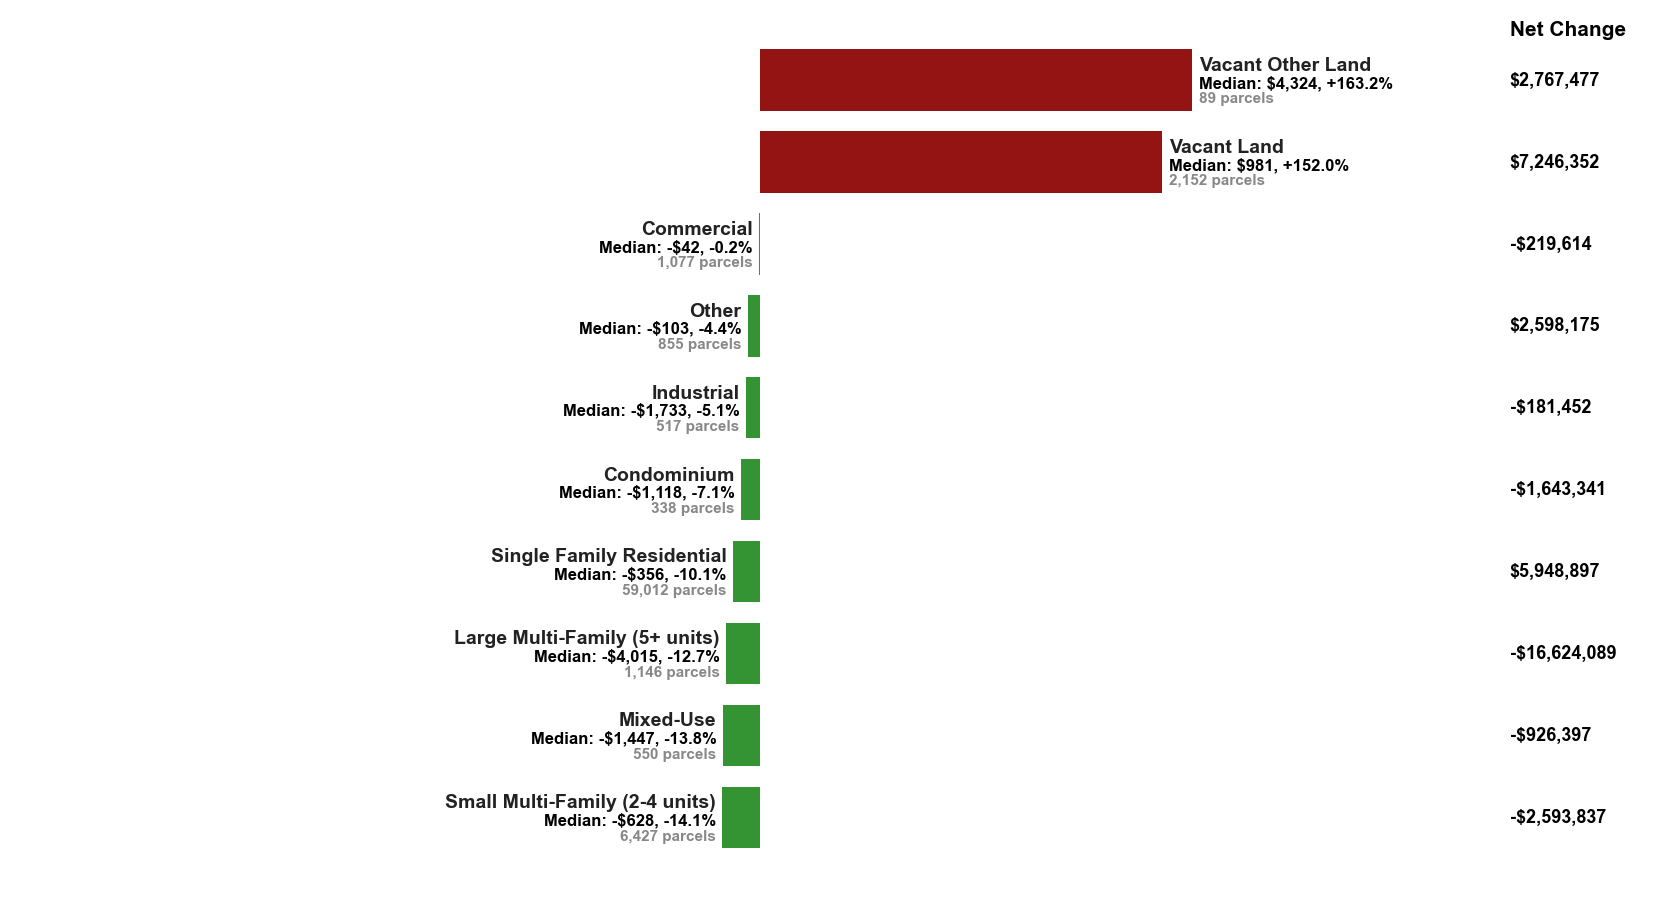

In [374]:
# Horizontal bar chart: median % change by category
import matplotlib.pyplot as plt

filtered = output_summary[output_summary['property_count'] > 50].copy()

categories = filtered['PROPERTY_CATEGORY'].tolist()
counts = filtered['property_count'].tolist()
median_pct_change = filtered['median_tax_change_pct'].tolist()
median_dollar_change = filtered['median_tax_change'].tolist()
total_tax_change = filtered['total_tax_change'].tolist() if 'total_tax_change' in filtered.columns else (filtered['mean_tax_change'] * filtered['property_count']).tolist()

sorted_idx = np.argsort(median_pct_change)
categories = [categories[i] for i in sorted_idx]
counts = [counts[i] for i in sorted_idx]
median_pct_change = [median_pct_change[i] for i in sorted_idx]
median_dollar_change = [median_dollar_change[i] for i in sorted_idx]
total_tax_change = [total_tax_change[i] for i in sorted_idx]

bar_colors = ['#8B0000' if val > 0 else '#228B22' for val in median_pct_change]

bar_height = 0.75
fig_height = len(categories) * 0.8 + 1.2
right_col_pad = 120
fig, ax = plt.subplots(figsize=(17, fig_height))

y = np.arange(len(categories))

ax.barh(y, median_pct_change, color=bar_colors, edgecolor='none',
        height=bar_height, alpha=0.92, linewidth=0, zorder=2)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

cat_offset = 0.18
med_offset = -0.03
count_offset = -0.23

max_abs = max(abs(min(median_pct_change)), abs(max(median_pct_change)))
right_col_x = max_abs + right_col_pad

ax.text(right_col_x, len(categories) - 0.5, 'Net Change', va='bottom', ha='left',
        fontsize=15, fontweight='bold', color='black', fontname='Arial')

for i, (cat, val, count, med_dol, tot_change) in enumerate(
    zip(categories, median_pct_change, counts, median_dollar_change, total_tax_change)):
    med_dol_str = f'${med_dol:,.0f}' if med_dol >= 0 else f'-${abs(med_dol):,.0f}'
    pct_str = f'{val:+.1f}%'
    median_combo = f'Median: {med_dol_str}, {pct_str}'

    xpos = val - 2.5 if val < 0 else val + 2.5
    ha = 'right' if val < 0 else 'left'

    ax.text(xpos, y[i]+cat_offset, cat, va='center', ha=ha,
            fontsize=14, fontweight='bold', color='#222', fontname='Arial')
    ax.text(xpos, y[i]+med_offset, median_combo, va='center', ha=ha,
            fontsize=12, fontweight='bold', color='black', fontname='Arial')
    ax.text(xpos, y[i]+count_offset, f'{count:,} parcels', va='center', ha=ha,
            fontsize=11, fontweight='bold', color='#888', fontname='Arial')

    tot_change_str = f'${tot_change:,.0f}' if tot_change >= 0 else f'-${abs(tot_change):,.0f}'
    ax.text(right_col_x, y[i], tot_change_str, va='center', ha='left',
            fontsize=13, fontweight='bold', color='black', fontname='Arial')

ax.set_xlim(-right_col_x, right_col_x + 60)
ax.set_yticks([])
ax.set_xticks([])

plt.tight_layout()
plt.show()

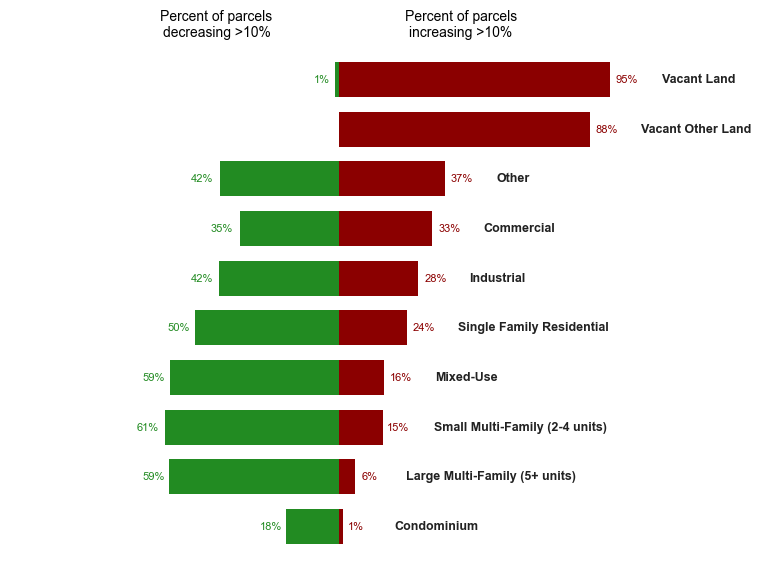

In [375]:
# Butterfly chart: percent of parcels increasing/decreasing >10%
import matplotlib.pyplot as plt

summary_filtered = output_summary[output_summary['property_count'] > 50].copy()
summary_sorted = summary_filtered.sort_values('pct_increase_gt_threshold', ascending=True)

categories_sorted = summary_sorted['PROPERTY_CATEGORY'].tolist()
pct_increase_sorted = summary_sorted['pct_increase_gt_threshold'].tolist()
pct_decrease_sorted = summary_sorted['pct_decrease_gt_threshold'].tolist()

pct_increase_int = [int(round(x)) for x in pct_increase_sorted]
pct_decrease_int = [int(round(x)) for x in pct_decrease_sorted]

y = np.arange(len(categories_sorted))
fig, ax = plt.subplots(figsize=(8, 6))

color_increase = '#8B0000'
color_decrease = '#228B22'

ax.barh(y, [-v for v in pct_decrease_sorted], color=color_decrease, edgecolor='none', height=0.7)
ax.barh(y, pct_increase_sorted, color=color_increase, edgecolor='none', height=0.7)

for i, (inc, dec) in enumerate(zip(pct_increase_int, pct_decrease_int)):
    if dec > 0:
        ax.text(-dec - 2, y[i], f'{dec}%', va='center', ha='right',
                fontsize=8, color=color_decrease, fontname='Arial')
    if inc > 0:
        ax.text(inc + 2, y[i], f'{inc}%', va='center', ha='left',
                fontsize=8, color=color_increase, fontname='Arial')

for i, (cat, inc) in enumerate(zip(categories_sorted, pct_increase_sorted)):
    xpos = inc + 18 if inc > 0 else 18
    ax.text(xpos, y[i], cat, va='center', ha='left',
            fontsize=9, fontweight='bold', color='#222', fontname='Arial')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.set_yticks([])
ax.set_xticks([])

max_val = max(max(pct_increase_sorted), max(pct_decrease_sorted))
ax.set_xlim(-max_val-20, max_val+48)

title_y = len(categories_sorted) - 0.2
ax.text(-max_val * 0.45, title_y, 'Percent of parcels\ndecreasing >10%',
        ha='center', va='bottom', fontsize=10, color='black', fontname='Arial',
        bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.15'))
ax.text(max_val * 0.45, title_y, 'Percent of parcels\nincreasing >10%',
        ha='center', va='bottom', fontsize=10, color='black', fontname='Arial',
        bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.15'))

plt.tight_layout()
plt.show()

## Step 7: Scatter Plots

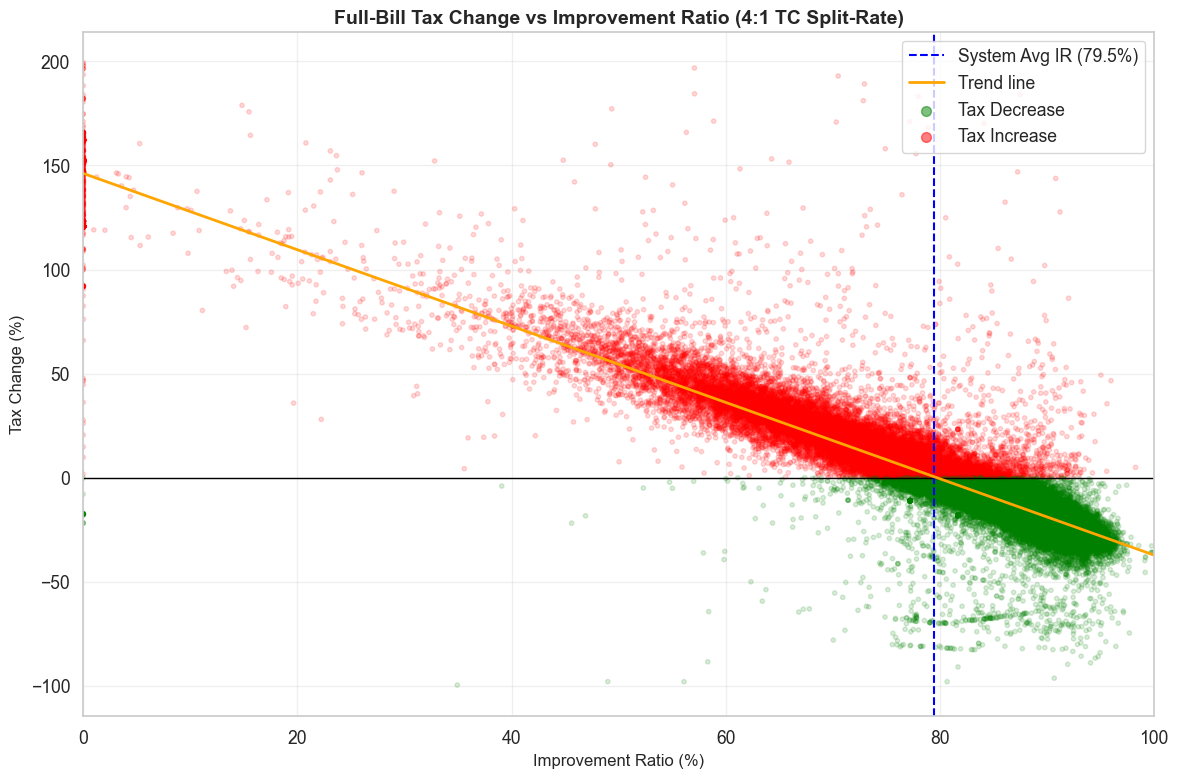


Plot shows 71,453 parcels
  Green (tax decrease): 47,288
  Red (tax increase): 24,165


In [376]:
# Scatter plot: Tax Change vs Improvement Ratio (full bill)
import matplotlib.pyplot as plt

# Use st_paul_city which already has the model results
plot_data = st_paul_city[
    (st_paul_city['current_tax'] > 100) & 
    (st_paul_city['IR'].notna()) &
    (st_paul_city['tax_change_pct_tc'].between(-100, 200))
].copy()

fig, ax = plt.subplots(figsize=(12, 8))

colors = np.where(plot_data['tax_change_pct_tc'] < 0, 'green', 'red')

ax.scatter(
    plot_data['IR'] * 100,
    plot_data['tax_change_pct_tc'],
    alpha=0.15, s=10, c=colors
)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

system_avg_ir = (st_paul_city['EMVBuilding1'].sum() / st_paul_city['EMVTotal1'].sum()) * 100
ax.axvline(x=system_avg_ir, color='blue', linestyle='--', linewidth=1.5,
           label=f'System Avg IR ({system_avg_ir:.1f}%)')

z = np.polyfit(plot_data['IR'] * 100, plot_data['tax_change_pct_tc'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 100, 100)
ax.plot(x_line, p(x_line), 'orange', linewidth=2, label='Trend line')

ax.scatter([], [], c='green', alpha=0.5, s=50, label='Tax Decrease')
ax.scatter([], [], c='red', alpha=0.5, s=50, label='Tax Increase')

ax.set_xlabel('Improvement Ratio (%)', fontsize=12)
ax.set_ylabel('Tax Change (%)', fontsize=12)
ax.set_title(f'Full-Bill Tax Change vs Improvement Ratio ({tc_land_improvement_ratio}:1 TC Split-Rate)',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

print(f'\nPlot shows {len(plot_data):,} parcels')
print(f'  Green (tax decrease): {(plot_data["tax_change_pct_tc"] < 0).sum():,}')
print(f'  Red (tax increase): {(plot_data["tax_change_pct_tc"] >= 0).sum():,}')

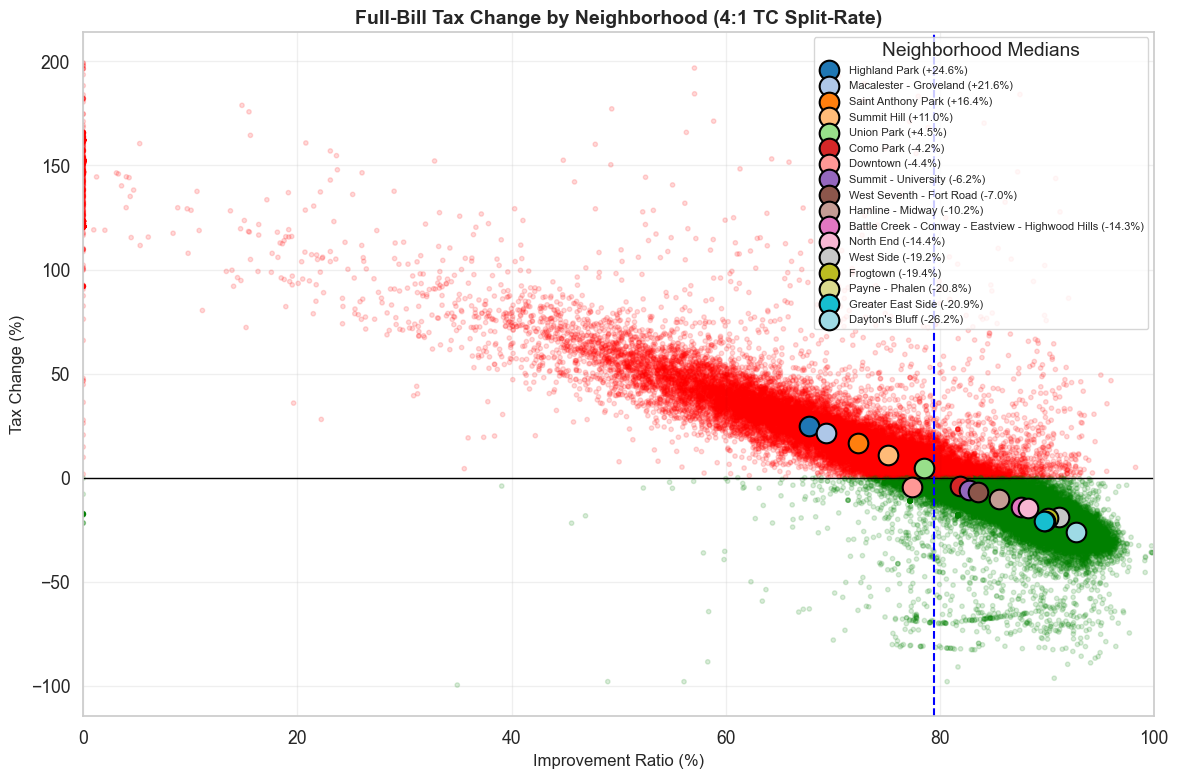


Plot shows 71,453 parcels across 17 neighborhoods


In [377]:
# Scatter plot: Tax Change by Neighborhood (full bill)
import matplotlib.pyplot as plt

# Spatial join to District Council neighborhoods
neighborhoods = gpd.read_file('data/st_paul/District_Councils_3386664414246726701')
neighborhoods = neighborhoods[['planning_1', 'geometry']].rename(columns={'planning_1': 'Neighborhood'})
neighborhoods = neighborhoods.to_crs(epsg=3857)

plot_source_3857 = st_paul_city.to_crs(epsg=3857)
plot_source_3857['centroid'] = plot_source_3857.geometry.centroid
centroids = gpd.GeoDataFrame(
    plot_source_3857.drop(columns='geometry'), geometry='centroid', crs='EPSG:3857'
)
plot_with_nbhd = gpd.sjoin(centroids, neighborhoods, how='left', predicate='within')
plot_with_nbhd = plot_with_nbhd.drop(columns=['index_right', 'centroid'])

plot_data = plot_with_nbhd[
    (plot_with_nbhd['current_tax'] > 100) & 
    (plot_with_nbhd['Neighborhood'].notna()) &
    (plot_with_nbhd['tax_change_pct_tc'].between(-100, 200))
].copy()

fig, ax = plt.subplots(figsize=(12, 8))

colors = np.where(plot_data['tax_change_pct_tc'] < 0, 'green', 'red')
ax.scatter(plot_data['IR'] * 100, plot_data['tax_change_pct_tc'],
           alpha=0.15, s=10, c=colors)

# Neighborhood medians
neighborhood_stats = plot_data.groupby('Neighborhood').agg({
    'IR': 'median',
    'tax_change_pct_tc': 'median',
    'TaxCapacity': 'count'
}).reset_index()
neighborhood_stats.columns = ['Neighborhood', 'median_IR', 'median_tax_change', 'count']
neighborhood_stats = neighborhood_stats.sort_values('median_tax_change', ascending=False)

cmap_colors = plt.cm.tab20(np.linspace(0, 1, len(neighborhood_stats)))
for i, row in enumerate(neighborhood_stats.itertuples()):
    ax.scatter(
        row.median_IR * 100, row.median_tax_change,
        s=200, c=[cmap_colors[i]], edgecolors='black', linewidths=1.5,
        label=f'{row.Neighborhood} ({row.median_tax_change:+.1f}%)', zorder=5
    )

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
system_avg_ir = (st_paul_city['EMVBuilding1'].sum() / st_paul_city['EMVTotal1'].sum()) * 100
ax.axvline(x=system_avg_ir, color='blue', linestyle='--', linewidth=1.5)

ax.set_xlabel('Improvement Ratio (%)', fontsize=12)
ax.set_ylabel('Tax Change (%)', fontsize=12)
ax.set_title(f'Full-Bill Tax Change by Neighborhood ({tc_land_improvement_ratio}:1 TC Split-Rate)',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, title='Neighborhood Medians')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

print(f'\nPlot shows {len(plot_data):,} parcels across {plot_data["Neighborhood"].nunique()} neighborhoods')

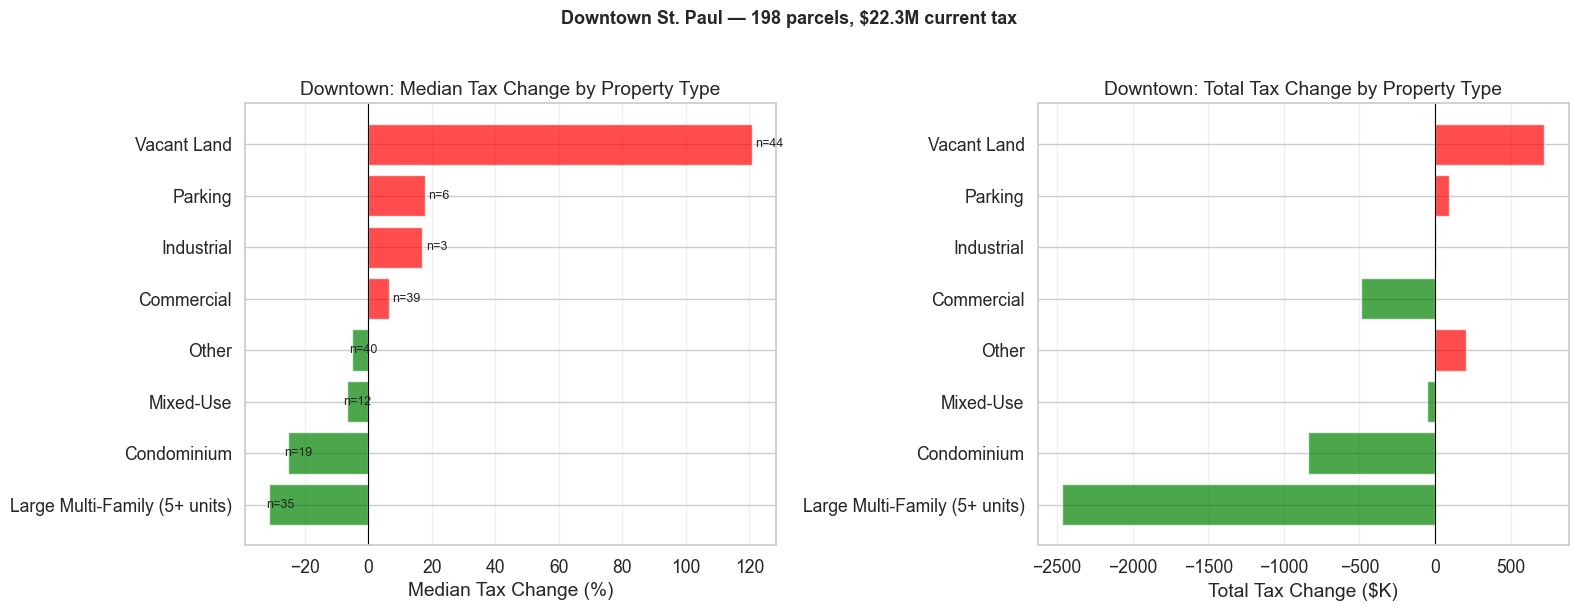


Downtown summary:
  Large Multi-Family (5+ units)       n=  35  median:  -31.3%  total: $  -2,467,160
  Condominium                         n=  19  median:  -25.4%  total: $    -837,102
  Mixed-Use                           n=  12  median:   -6.9%  total: $     -53,698
  Other                               n=  40  median:   -5.2%  total: $    +208,128
  Commercial                          n=  39  median:   +6.4%  total: $    -488,636
  Industrial                          n=   3  median:  +17.0%  total: $      +5,423
  Parking                             n=   6  median:  +17.9%  total: $     +93,354
  Vacant Land                         n=  44  median: +120.7%  total: $    +724,692


In [378]:
# Downtown tax change by property category
import matplotlib.pyplot as plt
import numpy as np

downtown = plot_with_nbhd[plot_with_nbhd['Neighborhood'] == 'Downtown'].copy()

dt_summary = downtown.groupby('PROPERTY_CATEGORY').agg(
    count=('tax_change_pct_tc', 'size'),
    median_change=('tax_change_pct_tc', 'median'),
    total_current=('current_tax', 'sum'),
    total_new=('new_tax_tc', 'sum')
).reset_index()
dt_summary['total_change'] = dt_summary['total_new'] - dt_summary['total_current']
dt_summary = dt_summary.sort_values('median_change')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: median % change by category
colors = ['green' if x < 0 else 'red' for x in dt_summary['median_change']]
bars = ax1.barh(dt_summary['PROPERTY_CATEGORY'], dt_summary['median_change'], color=colors, alpha=0.7)
for bar, count in zip(bars, dt_summary['count']):
    x = bar.get_width()
    ax1.text(x + (1 if x >= 0 else -1), bar.get_y() + bar.get_height()/2,
             f'n={count}', va='center', fontsize=9)
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.set_xlabel('Median Tax Change (%)')
ax1.set_title('Downtown: Median Tax Change by Property Type')
ax1.grid(True, alpha=0.3, axis='x')

# Right: total dollar change by category
colors2 = ['green' if x < 0 else 'red' for x in dt_summary['total_change']]
ax2.barh(dt_summary['PROPERTY_CATEGORY'], dt_summary['total_change'] / 1000, color=colors2, alpha=0.7)
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.set_xlabel('Total Tax Change ($K)')
ax2.set_title('Downtown: Total Tax Change by Property Type')
ax2.grid(True, alpha=0.3, axis='x')

plt.suptitle(f'Downtown St. Paul — {len(downtown):,} parcels, ${downtown["current_tax"].sum()/1e6:.1f}M current tax',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nDowntown summary:")
for _, row in dt_summary.iterrows():
    print(f"  {row['PROPERTY_CATEGORY']:35s} n={row['count']:>4}  median: {row['median_change']:>+6.1f}%  total: ${row['total_change']:>+12,.0f}")

## Step 8: Census Equity Analysis

In [379]:
# Get census data for Ramsey County
census_data, census_boundaries = get_census_data_with_boundaries(
    fips_code='27123',
    year=2022
)

census_boundaries = census_boundaries.set_crs(epsg=4326)
boundary_gdf = st_paul_city.to_crs(epsg=4326)

df = match_to_census_blockgroups(
    gdf=boundary_gdf,
    census_gdf=census_boundaries,
    join_type='left'
)

print(f'Census block groups: {len(census_boundaries)}')
print(f'Parcels with census data: {len(df)}')

Census block groups: 7753
Parcels with census data: 72389


In [380]:
import matplotlib.pyplot as plt
import seaborn as sns

def filter_data(df):
    df_filtered = df[df['median_income'] > 0].copy()
    non_vacant_df = df[(df['PROPERTY_CATEGORY'] != 'Vacant Land') & (df['median_income'] > 0)].copy()
    return df_filtered, non_vacant_df

def calculate_block_group_summary(df):
    df = df[df['median_income'] > 0].copy()
    summary = df.groupby('std_geoid').agg(
        median_income=('median_income', 'first'),
        minority_pct=('minority_pct', 'first'),
        black_pct=('black_pct', 'first'),
        total_current_tax=('current_tax', 'sum'),
        total_new_tax=('new_tax_tc', 'sum'),
        mean_tax_change=('tax_change_tc', 'mean'),
        median_tax_change=('tax_change_tc', 'median'),
        median_tax_change_pct=('tax_change_pct_tc', 'median'),
        parcel_count=('tax_change_tc', 'count'),
        has_vacant_land=('PROPERTY_CATEGORY', lambda x: 'Vacant Land' in x.values)
    ).reset_index()
    summary = summary[summary['median_income'] > 0].copy()
    summary['mean_tax_change_pct'] = ((summary['total_new_tax'] - summary['total_current_tax']) / 
                                    summary['total_current_tax']) * 100
    return summary

def weighted_median(values, weights):
    mask = (~np.isnan(values)) & (~np.isnan(weights))
    values = np.array(values)[mask]
    weights = np.array(weights)[mask]
    if len(values) == 0:
        return np.nan
    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]
    cumsum = np.cumsum(weights)
    cutoff = weights.sum() / 2.0
    return values[np.searchsorted(cumsum, cutoff)]

def create_quintile_summary(df, group_col, value_col):
    if group_col == 'median_income':
        df = df[df['median_income'] > 0].copy()
    df[f'{group_col}_quintile'] = pd.qcut(df[group_col], 5,
                                         labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)'])
    summary = df.groupby(f'{group_col}_quintile').apply(
        lambda g: pd.Series({
            'count': g['tax_change_tc'].count(),
            'mean_tax_change_pct': g['tax_change_pct_tc'].mean(),
            'median_tax_change_pct': weighted_median(g['tax_change_pct_tc'].values, np.ones(len(g))),
            'mean_value': g[value_col].mean()
        })
    ).reset_index()
    return summary

# Run analysis
gdf_filtered, non_vacant_gdf = filter_data(df)
print(f'Filtered parcels: {len(gdf_filtered):,}')
print(f'Non-vacant parcels: {len(non_vacant_gdf):,}')

income_quintile_summary = create_quintile_summary(gdf_filtered, 'median_income', 'median_income')
non_vacant_income_quintile_summary = create_quintile_summary(non_vacant_gdf, 'median_income', 'median_income')
minority_quintile_summary = create_quintile_summary(gdf_filtered, 'minority_pct', 'minority_pct')
non_vacant_minority_quintile_summary = create_quintile_summary(non_vacant_gdf, 'minority_pct', 'minority_pct')

print('\nTax impact by income quintile (all properties):')
display(income_quintile_summary)
print('\nTax impact by income quintile (excluding vacant land):')
display(non_vacant_income_quintile_summary)
print('\nTax impact by minority % quintile (all properties):')
display(minority_quintile_summary)
print('\nTax impact by minority % quintile (excluding vacant land):')
display(non_vacant_minority_quintile_summary)

Filtered parcels: 70,115
Non-vacant parcels: 68,004


/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_17550/3867654087.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_17550/3867654087.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_17550/3867654087.py:46: FutureWarning: The default of observed=False is deprecated and wil


Tax impact by income quintile (all properties):


/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_17550/3867654087.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_17550/3867654087.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_17550/3867654087.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the groupin

,median_income_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),14227.0,4.434299,-14.600722,44538.937088
1,Q2,13943.0,0.162700,-14.354386,64110.917543
2,Q3,13888.0,-5.469096,-14.138350,79714.596075
3,Q4,13868.0,-0.373057,-9.154311,98276.290115
4,Q5 (Highest),13997.0,15.120214,12.426198,135254.166465


...

,median_income_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),13602.0,-5.985859,-15.435293,44797.660401
1,Q2,13860.0,-6.726923,-15.703718,64641.744201
2,Q3,13308.0,-9.296348,-14.331319,80308.368994
3,Q4,13608.0,-3.249503,-9.652570,98936.101844
4,Q5 (Highest),13503.0,14.736319,12.877599,135903.759748



Tax impact by minority % quintile (all properties):


,minority_pct_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),14121.0,16.048136,10.916611,9.036987
1,Q2,13913.0,10.606896,4.127362,20.563233
2,Q3,14281.0,-2.564800,-12.002221,39.846771
3,Q4,13772.0,-7.704424,-19.302298,63.937303
4,Q5 (Highest),13836.0,-2.519804,-18.720734,80.088836



Tax impact by minority % quintile (excluding vacant land):


,minority_pct_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),13624.0,13.847295,10.029849,8.929531
1,Q2,13963.0,8.642495,4.075013,20.404741
2,Q3,13490.0,-6.745102,-12.109050,39.562034
3,Q4,13426.0,-15.136019,-19.890279,63.547641
4,Q5 (Highest),13378.0,-11.812780,-19.196093,79.904061


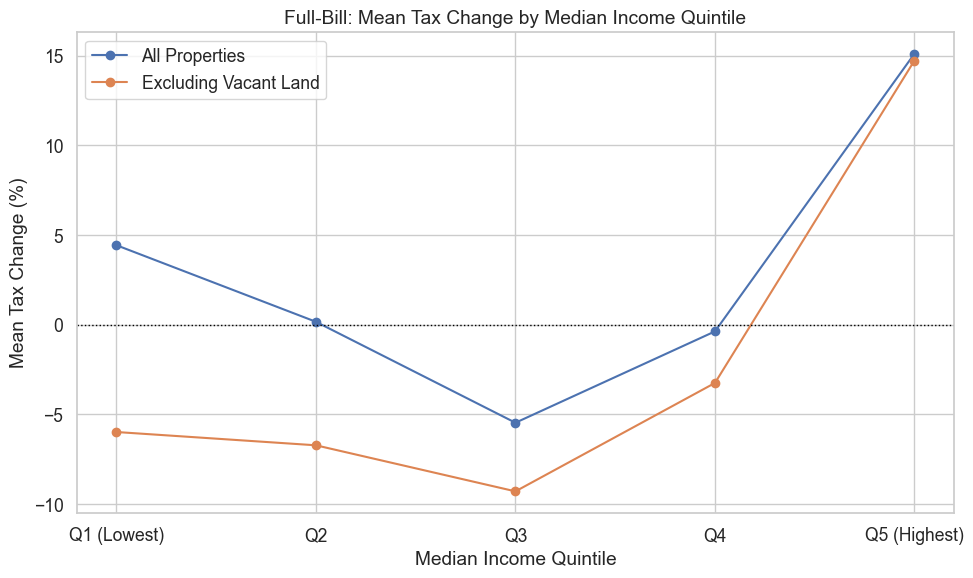

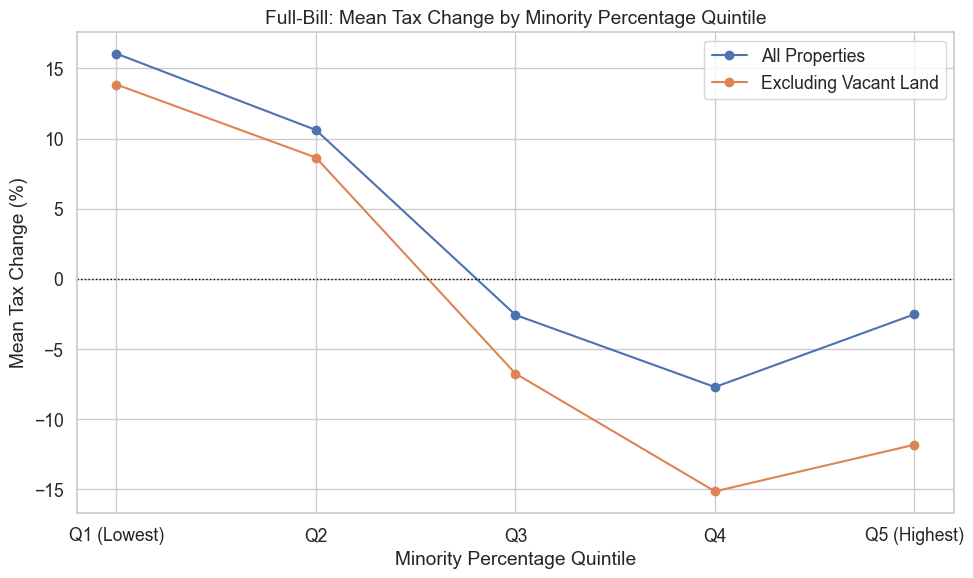

In [381]:
# Quintile line plots
plt.figure(figsize=(10, 6))
plt.plot(income_quintile_summary['median_income_quintile'],
         income_quintile_summary['mean_tax_change_pct'], marker='o', label='All Properties')
plt.plot(non_vacant_income_quintile_summary['median_income_quintile'],
         non_vacant_income_quintile_summary['mean_tax_change_pct'], marker='o', label='Excluding Vacant Land')
plt.xlabel('Median Income Quintile')
plt.ylabel('Mean Tax Change (%)')
plt.title('Full-Bill: Mean Tax Change by Median Income Quintile')
plt.legend()
plt.axhline(0, color='black', linewidth=1, linestyle='dotted')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(minority_quintile_summary['minority_pct_quintile'],
         minority_quintile_summary['mean_tax_change_pct'], marker='o', label='All Properties')
plt.plot(non_vacant_minority_quintile_summary['minority_pct_quintile'],
         non_vacant_minority_quintile_summary['mean_tax_change_pct'], marker='o', label='Excluding Vacant Land')
plt.xlabel('Minority Percentage Quintile')
plt.ylabel('Mean Tax Change (%)')
plt.title('Full-Bill: Mean Tax Change by Minority Percentage Quintile')
plt.legend()
plt.axhline(0, color='black', linewidth=1, linestyle='dotted')
plt.tight_layout()
plt.show()

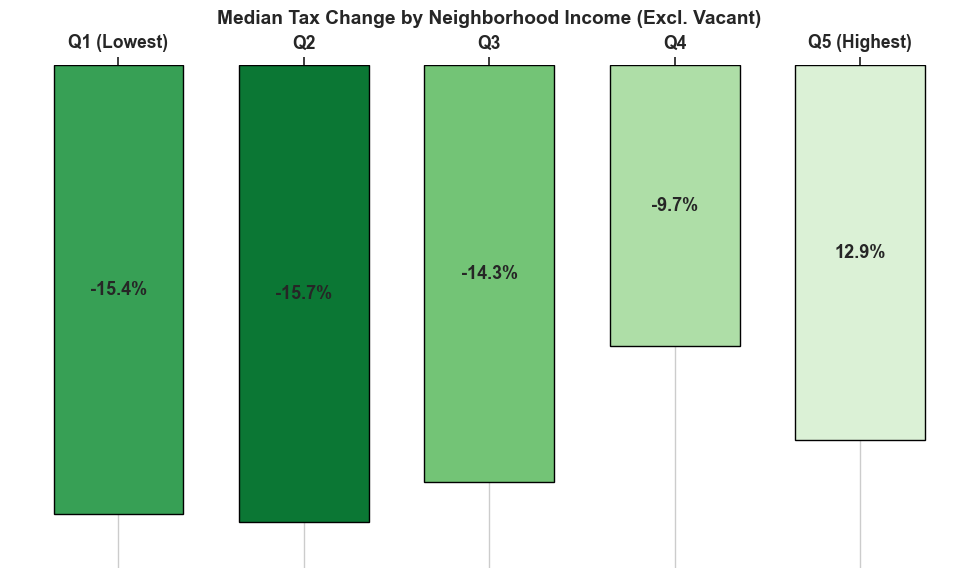

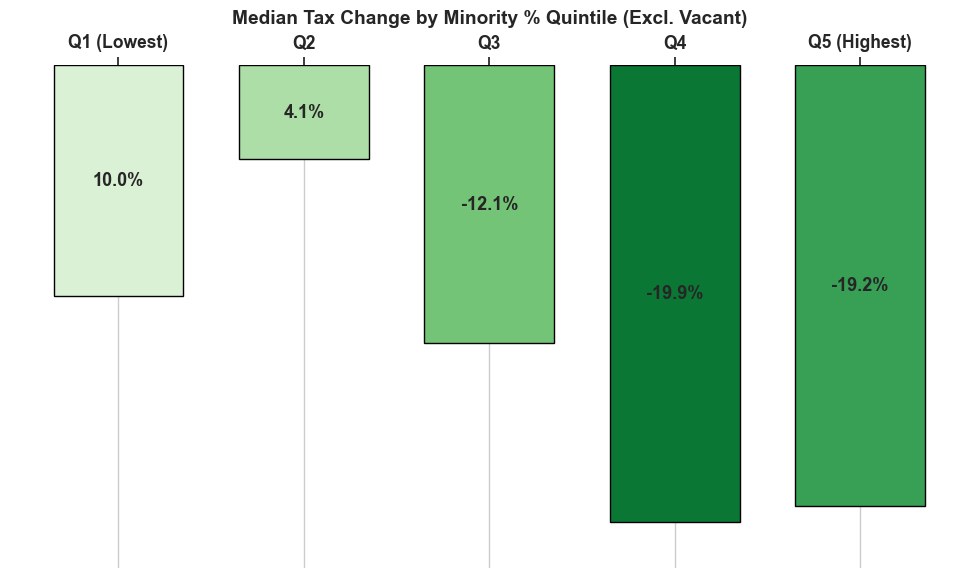

In [382]:
# Inverted bar charts: median tax change by quintile (excluding vacant land)
sns.set_theme(style='whitegrid', font_scale=1.15)

# Income quintiles
fig, ax = plt.subplots(figsize=(10, 6))
vals = non_vacant_income_quintile_summary['median_tax_change_pct']
labels = non_vacant_income_quintile_summary['median_income_quintile']
colors = sns.color_palette('Greens', n_colors=len(vals))
color_map = [colors[i] for i in np.argsort(np.argsort(-vals))]

bars = ax.bar(labels, np.abs(vals), color=color_map, edgecolor='black', width=0.7)
ax.invert_yaxis()
ax.yaxis.set_visible(False)
ax.set_title('Median Tax Change by Neighborhood Income (Excl. Vacant)', weight='bold', pad=30)
sns.despine(left=True, right=True, top=True, bottom=True)
for bar, val in zip(bars, vals):
    ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2),
                ha='center', va='center', fontsize=13, fontweight='bold')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')
ax.set_ylim(np.abs(vals).max() * 1.1, 0)
plt.tight_layout()
plt.show()

# Minority quintiles
fig, ax = plt.subplots(figsize=(10, 6))
vals2 = non_vacant_minority_quintile_summary['median_tax_change_pct']
labels2 = non_vacant_minority_quintile_summary['minority_pct_quintile']
colors2 = sns.color_palette('Greens', n_colors=len(vals2))
color_map2 = [colors2[i] for i in np.argsort(np.argsort(-vals2))]

bars2 = ax.bar(labels2, np.abs(vals2), color=color_map2, edgecolor='black', width=0.7)
ax.invert_yaxis()
ax.yaxis.set_visible(False)
ax.set_title('Median Tax Change by Minority % Quintile (Excl. Vacant)', weight='bold', pad=30)
sns.despine(left=True, right=True, top=True, bottom=True)
for bar, val in zip(bars2, vals2):
    ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2),
                ha='center', va='center', fontsize=13, fontweight='bold')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')
ax.set_ylim(np.abs(vals2).max() * 1.1, 0)
plt.tight_layout()
plt.show()

Single family parcels: 57,322


/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_17550/3867654087.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_17550/3867654087.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_17550/3867654087.py:46: FutureWarning: The default of observed=False is deprecated and wil

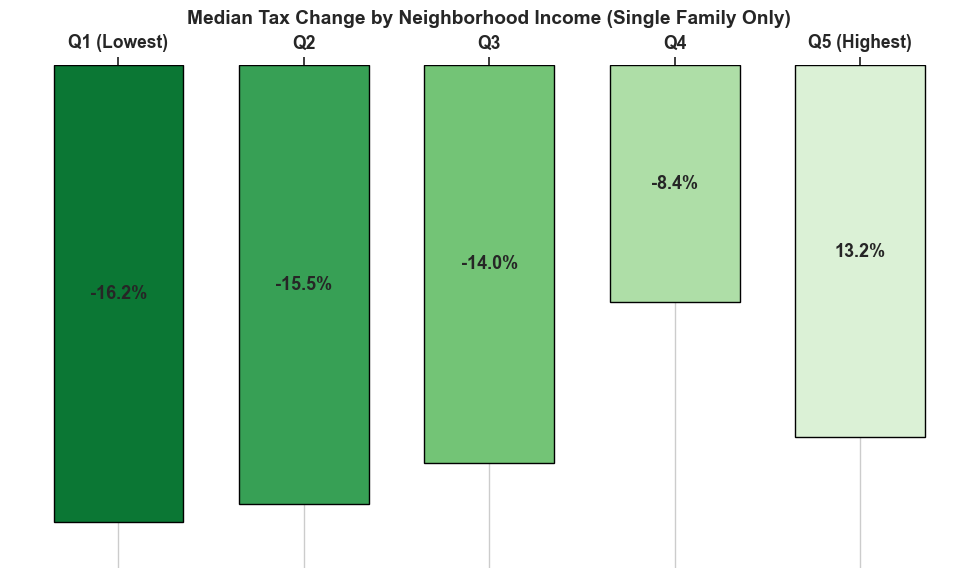

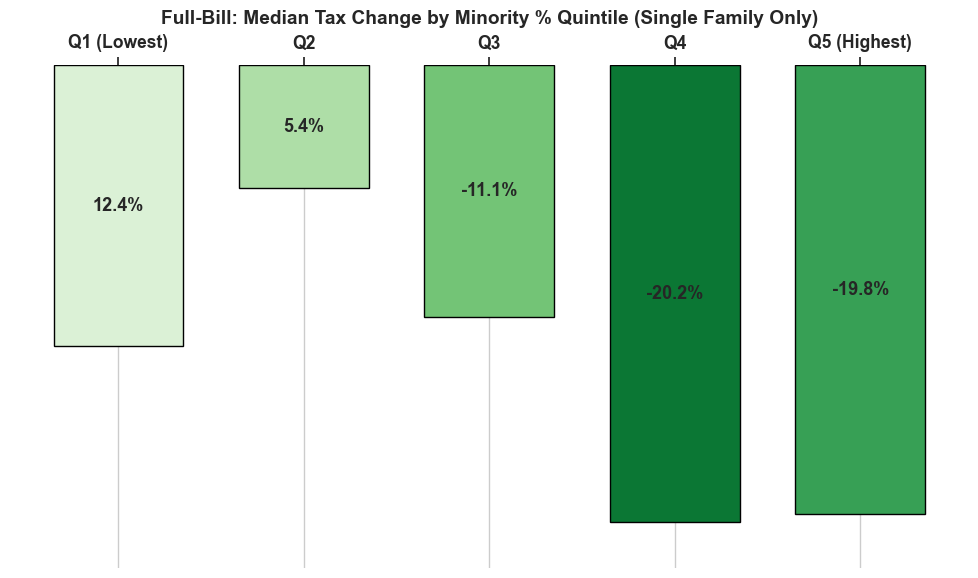

In [383]:
# Inverted bar charts: single family residential only
sfr = df[(df['PROPERTY_CATEGORY'] == 'Single Family Residential') & (df['median_income'] > 0)].copy()
print(f'Single family parcels: {len(sfr):,}')

sfr_income_quintile = create_quintile_summary(sfr, 'median_income', 'median_income')
sfr_minority_quintile = create_quintile_summary(sfr, 'minority_pct', 'minority_pct')

sns.set_theme(style='whitegrid', font_scale=1.15)

# Income quintiles - single family
fig, ax = plt.subplots(figsize=(10, 6))
vals = sfr_income_quintile['median_tax_change_pct']
labels = sfr_income_quintile['median_income_quintile']
colors = sns.color_palette('Greens', n_colors=len(vals))
color_map = [colors[i] for i in np.argsort(np.argsort(-vals))]
bars = ax.bar(labels, np.abs(vals), color=color_map, edgecolor='black', width=0.7)
ax.invert_yaxis()
ax.yaxis.set_visible(False)
ax.set_title('Median Tax Change by Neighborhood Income (Single Family Only)', weight='bold', pad=30)
sns.despine(left=True, right=True, top=True, bottom=True)
for bar, val in zip(bars, vals):
    ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2),
                ha='center', va='center', fontsize=13, fontweight='bold')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')
ax.set_ylim(np.abs(vals).max() * 1.1, 0)
plt.tight_layout()
plt.show()

# Minority quintiles - single family
fig, ax = plt.subplots(figsize=(10, 6))
vals2 = sfr_minority_quintile['median_tax_change_pct']
labels2 = sfr_minority_quintile['minority_pct_quintile']
colors2 = sns.color_palette('Greens', n_colors=len(vals2))
color_map2 = [colors2[i] for i in np.argsort(np.argsort(-vals2))]
bars2 = ax.bar(labels2, np.abs(vals2), color=color_map2, edgecolor='black', width=0.7)
ax.invert_yaxis()
ax.yaxis.set_visible(False)
ax.set_title('Full-Bill: Median Tax Change by Minority % Quintile (Single Family Only)', weight='bold', pad=30)
sns.despine(left=True, right=True, top=True, bottom=True)
for bar, val in zip(bars2, vals2):
    ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2),
                ha='center', va='center', fontsize=13, fontweight='bold')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')
ax.set_ylim(np.abs(vals2).max() * 1.1, 0)
plt.tight_layout()
plt.show()


Multifamily parcels: 7,378


/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_17550/3867654087.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_17550/3867654087.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_17550/3867654087.py:46: FutureWarning: The default of observed=False is deprecated and wil

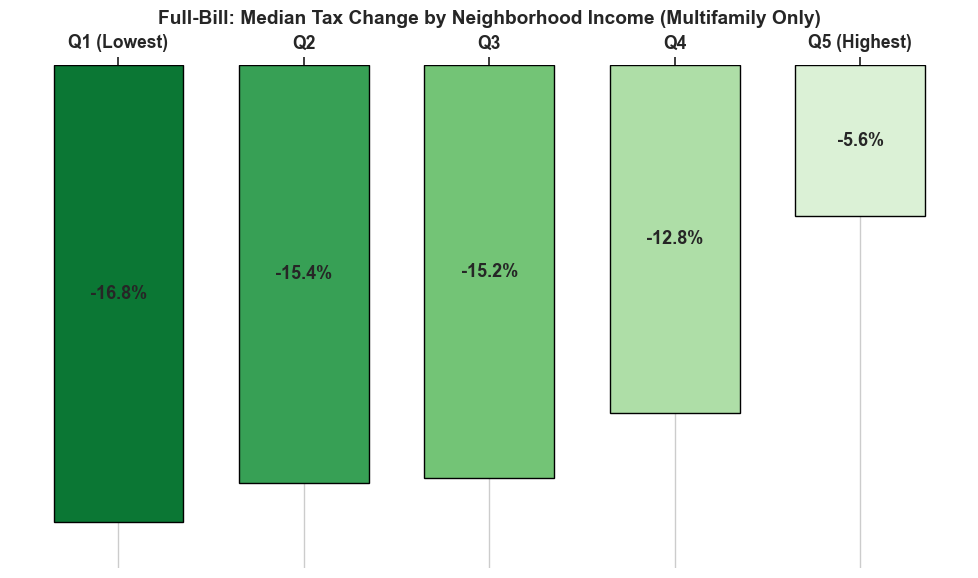

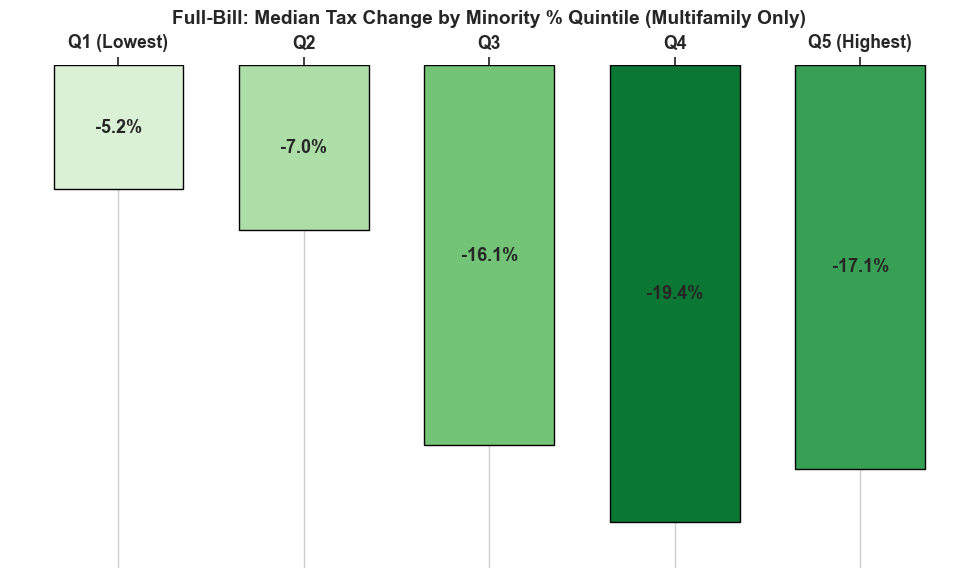

In [384]:
# Inverted bar charts: multifamily residential only
mfr = df[(df['PROPERTY_CATEGORY'].isin(['Small Multi-Family (2-4 units)', 'Large Multi-Family (5+ units)'])) & (df['median_income'] > 0)].copy()
print(f'Multifamily parcels: {len(mfr):,}')

mfr_income_quintile = create_quintile_summary(mfr, 'median_income', 'median_income')
mfr_minority_quintile = create_quintile_summary(mfr, 'minority_pct', 'minority_pct')

sns.set_theme(style='whitegrid', font_scale=1.15)

# Income quintiles - multifamily
fig, ax = plt.subplots(figsize=(10, 6))
vals = mfr_income_quintile['median_tax_change_pct']
labels = mfr_income_quintile['median_income_quintile']
colors = sns.color_palette('Greens', n_colors=len(vals))
color_map = [colors[i] for i in np.argsort(np.argsort(-vals))]
bars = ax.bar(labels, np.abs(vals), color=color_map, edgecolor='black', width=0.7)
ax.invert_yaxis()
ax.yaxis.set_visible(False)
ax.set_title('Full-Bill: Median Tax Change by Neighborhood Income (Multifamily Only)', weight='bold', pad=30)
sns.despine(left=True, right=True, top=True, bottom=True)
for bar, val in zip(bars, vals):
    ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2),
                ha='center', va='center', fontsize=13, fontweight='bold')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')
ax.set_ylim(np.abs(vals).max() * 1.1, 0)
plt.tight_layout()
plt.show()

# Minority quintiles - multifamily
fig, ax = plt.subplots(figsize=(10, 6))
vals2 = mfr_minority_quintile['median_tax_change_pct']
labels2 = mfr_minority_quintile['minority_pct_quintile']
colors2 = sns.color_palette('Greens', n_colors=len(vals2))
color_map2 = [colors2[i] for i in np.argsort(np.argsort(-vals2))]
bars2 = ax.bar(labels2, np.abs(vals2), color=color_map2, edgecolor='black', width=0.7)
ax.invert_yaxis()
ax.yaxis.set_visible(False)
ax.set_title('Full-Bill: Median Tax Change by Minority % Quintile (Multifamily Only)', weight='bold', pad=30)
sns.despine(left=True, right=True, top=True, bottom=True)
for bar, val in zip(bars2, vals2):
    ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2),
                ha='center', va='center', fontsize=13, fontweight='bold')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')
ax.set_ylim(np.abs(vals2).max() * 1.1, 0)
plt.tight_layout()
plt.show()


## Step 9: The Incentive Effect — Full Bill

Under HF 1342, the **entire tax bill** is reallocated. This means the rate advantage for improvements is much larger than the city-only analysis:

- Current system: every \$1 of new improvement TC is taxed at the **full combined rate** (~1.55)
- Split-rate system: every \$1 of new improvement TC is taxed at the **improvement millage** (~0.94)

The rate advantage per dollar of improvement is ~0.61 under the full bill, compared to ~0.21 in the city-only model. This means every dollar of investment saves roughly 3× as much in taxes.

In [385]:
# Effective full tax rate from our working set
full_tax_rate = current_revenue / st_paul_city['TaxCapacity'].sum()
residential_class_rate = 0.01  # MN class rate for residential homestead under $500K

print(f'Full effective tax rate: {full_tax_rate:.4f} per $ of TC')
print(f'Improvement millage:    {tc_imp_millage:.4f} per $1000 of TC = {tc_imp_millage/1000:.6f} per $ of TC')
print(f'Rate advantage:         {full_tax_rate - tc_imp_millage/1000:.4f} per $ of TC')
print(f'\nFor comparison, city-only NTC rate is {OFFICIAL_CITY_TAX_RATE:.4f}')
print(f'Full bill captures {full_tax_rate / OFFICIAL_CITY_TAX_RATE:.1f}x more revenue per $ of TC')

Full effective tax rate: 1.5472 per $ of TC
Improvement millage:    929.0008 per $1000 of TC = 0.929001 per $ of TC
Rate advantage:         0.6182 per $ of TC

For comparison, city-only NTC rate is 0.5270
Full bill captures 2.9x more revenue per $ of TC


1056 EVERETT CT
  Current full tax: $5,696
  Split-rate tax:   $7,807 (+$2,111)
  Crossover at $341,519 in improvements


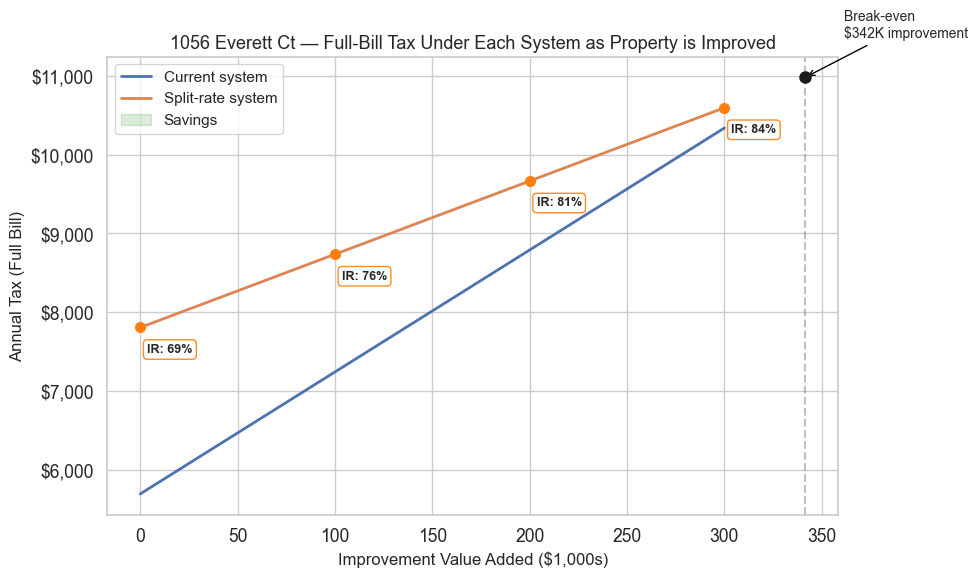

In [386]:
# 1056 Everett Ct: how improvement changes the tax comparison (full bill)
prop = st_paul_city[st_paul_city['SiteAddress'].str.contains('1056 EVERETT', case=False, na=False)].iloc[0]

current_tax_base = prop['current_tax']
split_tax_base = prop['new_tax_tc']
emv_bldg = prop['EMVBuilding1']
emv_total = prop['EMVTotal1']

reno_values = np.arange(0, 300_001, 1_000)

# Full bill: marginal rate is full_tax_rate per $ of TC
current_system_tax = current_tax_base + full_tax_rate * reno_values * residential_class_rate
split_rate_tax = split_tax_base + (tc_imp_millage / 1000) * reno_values * residential_class_rate

# Crossover
gap = split_tax_base - current_tax_base
rate_advantage = full_tax_rate - tc_imp_millage / 1000
crossover = gap / (rate_advantage * residential_class_rate)
crossover_tax = current_tax_base + full_tax_rate * crossover * residential_class_rate

print(f'1056 EVERETT CT')
print(f'  Current full tax: ${current_tax_base:,.0f}')
print(f'  Split-rate tax:   ${split_tax_base:,.0f} (+${gap:,.0f})')
print(f'  Crossover at ${crossover:,.0f} in improvements')

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(reno_values / 1000, current_system_tax, label='Current system', linewidth=2)
ax.plot(reno_values / 1000, split_rate_tax, label='Split-rate system', linewidth=2)

mask = reno_values >= crossover
ax.fill_between(reno_values[mask] / 1000, split_rate_tax[mask], current_system_tax[mask],
                alpha=0.15, color='green', label='Savings')

ax.axvline(x=crossover / 1000, color='gray', linestyle='--', alpha=0.5)
ax.plot(crossover / 1000, crossover_tax, 'ko', markersize=8, zorder=5)
ax.annotate(f'Break-even\n${crossover/1000:.0f}K improvement',
            xy=(crossover / 1000, crossover_tax),
            xytext=(crossover / 1000 + 20, crossover_tax + 500),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

for reno in [0, 100_000, 200_000, 300_000]:
    ir = (emv_bldg + reno) / (emv_total + reno)
    idx = int(reno / 1000)
    tax_at_point = split_rate_tax[idx]
    ax.plot(reno / 1000, tax_at_point, 'o', color='tab:orange', markersize=7, zorder=5)
    ax.annotate(f'IR: {ir*100:.0f}%',
                xy=(reno / 1000, tax_at_point),
                xytext=(5, -18), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='tab:orange', alpha=0.9))

ax.set_xlabel('Improvement Value Added ($1,000s)', fontsize=12)
ax.set_ylabel('Annual Tax (Full Bill)', fontsize=12)
ax.set_title('1056 Everett Ct — Full-Bill Tax Under Each System as Property is Improved', fontsize=13)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

719 Hague Ave starts with a **tax cut** under the split-rate — the lines are flipped. Because improvements are taxed at the lower rate, every dollar of investment widens the savings further. With the full bill, the savings are even larger.

719 HAGUE AVE
  Current full tax: $8,312
  Split-rate tax:   $7,337 (-$976)
  Savings grow from $976/year to $2,830/year ($300K improvement)


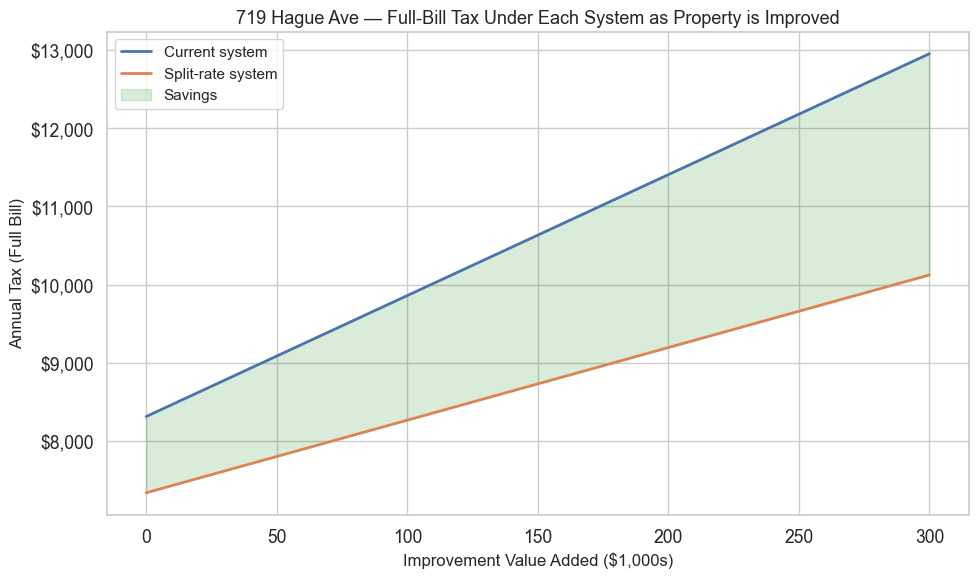

In [387]:
# 719 Hague Ave: split-rate already cheaper, improvement widens the gap (full bill)
prop = st_paul_city[st_paul_city['SiteAddress'].str.contains('719 HAGUE', case=False, na=False)].iloc[0]

current_tax_base = prop['current_tax']
split_tax_base = prop['new_tax_tc']

reno_values = np.arange(0, 300_001, 1_000)

current_system_tax = current_tax_base + full_tax_rate * reno_values * residential_class_rate
split_rate_tax = split_tax_base + (tc_imp_millage / 1000) * reno_values * residential_class_rate

savings_at_0 = current_tax_base - split_tax_base
savings_at_300k = current_system_tax[-1] - split_rate_tax[-1]

print(f'719 HAGUE AVE')
print(f'  Current full tax: ${current_tax_base:,.0f}')
print(f'  Split-rate tax:   ${split_tax_base:,.0f} (-${savings_at_0:,.0f})')
print(f'  Savings grow from ${savings_at_0:,.0f}/year to ${savings_at_300k:,.0f}/year ($300K improvement)')

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(reno_values / 1000, current_system_tax, label='Current system', linewidth=2)
ax.plot(reno_values / 1000, split_rate_tax, label='Split-rate system', linewidth=2)

ax.fill_between(reno_values / 1000, split_rate_tax, current_system_tax, alpha=0.15, color='green', label='Savings')

ax.set_xlabel('Improvement Value Added ($1,000s)', fontsize=12)
ax.set_ylabel('Annual Tax (Full Bill)', fontsize=12)
ax.set_title('719 Hague Ave — Full-Bill Tax Under Each System as Property is Improved', fontsize=13)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

## Step 10: TIF vs LVT — Two Approaches to the Same Problem

Tax Increment Financing (TIF) and land value taxation both aim to incentivize development, but through very different mechanisms:

| | TIF | LVT |
|---|---|---|
| **Mechanism** | Diverts tax *increment* from general levy to repay development subsidy | Taxes land at a higher rate, improvements at a lower rate |
| **Who benefits** | Specific parcels in designated TIF districts | All improved properties system-wide |
| **Revenue effect** | Removes ~$41M from the general levy | Revenue-neutral reallocation |
| **Duration** | Temporary (typically 25 years), then increment returns | Permanent structural change |

St. Paul's TIF parcels have a **median improvement ratio of 99%** — they are among the most heavily improved properties in the city. Under LVT, these parcels would receive large tax cuts *without* needing TIF (once developed). This section asks: what would TIF parcels look like under the split-rate model?

**Important caveat:** We are observing TIF parcels at their *improved end state*, not at the point of intervention. Most of these parcels were likely vacant or underimproved when their TIF districts were created — that's why they received TIF in the first place. The TIF subsidy funded infrastructure, the developer built, and now 15-25 years later we see parcels with 99% improvement ratios. The question isn't whether TIF worked for these parcels (it did), but whether LVT could achieve the same outcome for future development without the revenue diversion, district designations, and administrative overhead that TIF requires.

In [388]:
# TIF parcels: what they pay now vs what they'd pay under LVT
tif_parcels = st_paul_gdf[
    st_paul_gdf['in_tif'] &
    (st_paul_gdf['TaxCapacity'] > 0) &
    (st_paul_gdf['EMVTotal1'] > 0)
].copy()

# Calculate IR and split TC (same approach as main model)
tif_parcels['IR'] = tif_parcels['EMVBuilding1'] / tif_parcels['EMVTotal1']
tif_parcels['IR'] = tif_parcels['IR'].fillna(0)
tif_parcels['TaxCapacity_Land'] = (1 - tif_parcels['IR']) * tif_parcels['TaxCapacity']
tif_parcels['TaxCapacity_Improvements'] = tif_parcels['IR'] * tif_parcels['TaxCapacity']

# Apply the SAME millage rates from the full-bill model
tif_parcels['current_tax'] = tif_parcels['TotalTax1']
tif_parcels['lvt_tax'] = (
    tif_parcels['TaxCapacity_Land'] * tc_land_millage / 1000 +
    tif_parcels['TaxCapacity_Improvements'] * tc_imp_millage / 1000
)
tif_parcels['lvt_change'] = tif_parcels['lvt_tax'] - tif_parcels['current_tax']
tif_parcels['lvt_change_pct'] = np.where(
    tif_parcels['current_tax'] > 0,
    (tif_parcels['lvt_change'] / tif_parcels['current_tax']) * 100,
    0
)

print(f'TIF parcels analyzed: {len(tif_parcels):,}')
print(f'Median IR: {tif_parcels["IR"].median()*100:.1f}% (city-taxable median: {st_paul_city["IR"].median()*100:.1f}%)')
print(f'\nTIF PARCELS: CURRENT TAX vs HYPOTHETICAL LVT TAX')
print(f'  Current total tax (TotalTax1):  ${tif_parcels["current_tax"].sum():,.0f}')
print(f'  Hypothetical LVT tax:           ${tif_parcels["lvt_tax"].sum():,.0f}')
print(f'  Difference:                     ${tif_parcels["lvt_change"].sum():,.0f}')
print(f'  Median parcel change:           {tif_parcels["lvt_change_pct"].median():+.1f}%')
print(f'\n  Parcels that would pay LESS under LVT: {(tif_parcels["lvt_change"] < 0).sum():,} ({(tif_parcels["lvt_change"] < 0).mean()*100:.0f}%)')
print(f'  Parcels that would pay MORE under LVT: {(tif_parcels["lvt_change"] > 0).sum():,} ({(tif_parcels["lvt_change"] > 0).mean()*100:.0f}%)')

TIF parcels analyzed: 2,543
Median IR: 99.2% (city-taxable median: 85.3%)

TIF PARCELS: CURRENT TAX vs HYPOTHETICAL LVT TAX
  Current total tax (TotalTax1):  $51,264,274
  Hypothetical LVT tax:           $42,675,080
  Difference:                     $-8,590,432
  Median parcel change:           -37.2%

  Parcels that would pay LESS under LVT: 2,154 (85%)
  Parcels that would pay MORE under LVT: 387 (15%)


In [389]:
# How much revenue does TIF divert from the general levy?
tif_ntc_official = 28_684_858  # Official TIF NTC (increment only)
tif_levy_official = 41_313_536  # Official TIF Levy

city_share_of_tif = tif_ntc_official * OFFICIAL_CITY_TAX_RATE
full_bill_share_of_tif = tif_levy_official

print('TIF REVENUE DIVERSION (Official MN Dept of Revenue)')
print(f'  TIF NTC (increment):          ${tif_ntc_official:,.0f}')
print(f'  TIF Levy (all jurisdictions):  ${tif_levy_official:,.0f}')
print(f'  City share of TIF levy:        ${city_share_of_tif:,.0f}')
print(f'  County share:                  ${tif_ntc_official * 0.4361:,.0f}')
print(f'  School share:                  ${tif_ntc_official * 0.3448:,.0f}')
print(f'  Special district share:        ${tif_ntc_official * 0.1328:,.0f}')

print(f'\nPERSPECTIVE')
print(f'  Full-bill tax base (city-taxable): ${current_revenue:,.0f}')
print(f'  TIF levy diverted:                 ${tif_levy_official:,.0f} ({tif_levy_official/current_revenue*100:.1f}% of base)')
print(f'  If TIF parcels joined LVT district, their LVT tax would be: ${tif_parcels["lvt_tax"].sum():,.0f}')
print(f'  vs their current TotalTax1:                                  ${tif_parcels["current_tax"].sum():,.0f}')

TIF REVENUE DIVERSION (Official MN Dept of Revenue)
  TIF NTC (increment):          $28,684,858
  TIF Levy (all jurisdictions):  $41,313,536
  City share of TIF levy:        $15,116,920
  County share:                  $12,509,467
  School share:                  $9,890,539
  Special district share:        $3,809,349

PERSPECTIVE
  Full-bill tax base (city-taxable): $559,086,384
  TIF levy diverted:                 $41,313,536 (7.4% of base)
  If TIF parcels joined LVT district, their LVT tax would be: $42,675,080
  vs their current TotalTax1:                                  $51,264,274


In [390]:
# TIF district breakdown: current tax vs hypothetical LVT
district_summary = tif_parcels.groupby('TIFDistrict').agg(
    parcels=('TaxCapacity', 'count'),
    total_tc=('TaxCapacity', 'sum'),
    current_tax=('current_tax', 'sum'),
    lvt_tax=('lvt_tax', 'sum'),
    median_ir=('IR', 'median'),
).copy()
district_summary['lvt_change'] = district_summary['lvt_tax'] - district_summary['current_tax']
district_summary['change_pct'] = (district_summary['lvt_change'] / district_summary['current_tax'] * 100)
district_summary = district_summary.sort_values('total_tc', ascending=False)

print('TOP TIF DISTRICTS: CURRENT TAX vs HYPOTHETICAL LVT')
print(f"{'District':<45} {'Parcels':>7} {'Median IR':>10} {'Current Tax':>14} {'LVT Tax':>14} {'Change':>14} {'Chg %':>7}")
print('-' * 115)
for name, row in district_summary.head(12).iterrows():
    # Truncate long names
    short_name = name[:43] if len(name) > 43 else name
    print(f"{short_name:<45} {int(row['parcels']):>7} {row['median_ir']*100:>9.1f}% ${row['current_tax']:>12,.0f} ${row['lvt_tax']:>12,.0f} ${row['lvt_change']:>12,.0f} {row['change_pct']:>+6.1f}%")

TOP TIF DISTRICTS: CURRENT TAX vs HYPOTHETICAL LVT
District                                      Parcels  Median IR    Current Tax        LVT Tax         Change   Chg %
-------------------------------------------------------------------------------------------------------------------
282:MN EVENTS DIST                                694      99.2% $  10,769,473 $   9,113,847 $  -1,655,626  -15.4%
0322-0 STP Ford site                              176       0.0% $   6,498,469 $   8,457,439 $   1,958,971  +30.1%
225:Rvrfrt Ren - Upper Landing                    583      89.8% $   3,479,549 $   2,401,248 $  -1,078,301  -31.0%
213:BLOCK #39/LAWSON;OLD-6N                         3      91.4% $   2,761,779 $   1,964,305 $    -797,474  -28.9%
249:WESTMINSTER                                    16      77.1% $   2,530,198 $   1,840,164 $    -690,034  -27.3%
212:Block #4/Mn Mutual;Old-5N                       1      92.4% $   2,220,275 $   1,506,432 $    -713,843  -32.2%
234:Phalen Village - Unco

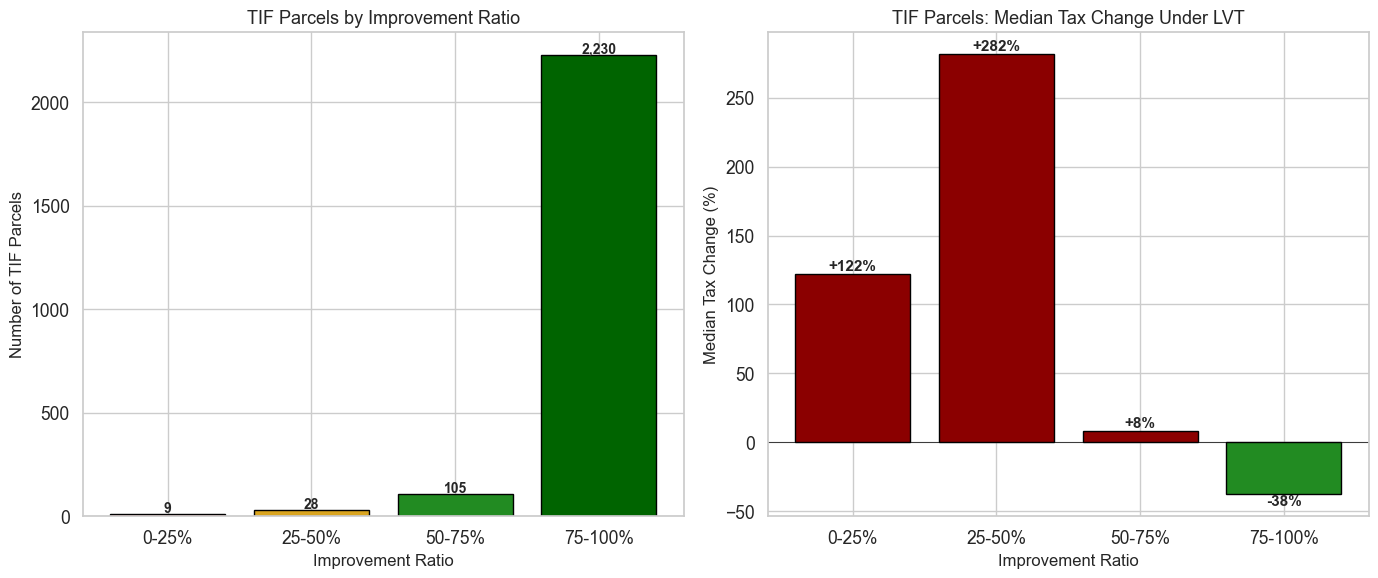


85% of TIF parcels would pay less under LVT.
The higher the IR, the larger the tax cut — exactly the properties TIF was designed to create.


In [391]:
# Chart: TIF parcels — distribution and tax change by IR quartile (equal IR ranges)
import matplotlib.pyplot as plt

tif_plot = tif_parcels[tif_parcels['current_tax'] > 0].copy()
tif_plot['ir_quartile'] = pd.cut(tif_plot['IR'], bins=[0, 0.25, 0.50, 0.75, 1.0],
                                  labels=['0-25%', '25-50%', '50-75%', '75-100%'])

quartile_summary = tif_plot.groupby('ir_quartile', observed=True).agg(
    parcels=('TaxCapacity', 'count'),
    median_ir=('IR', 'median'),
    median_change_pct=('lvt_change_pct', 'median'),
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: parcel counts by IR range
colors = ['#8B0000', '#DAA520', '#228B22', '#006400']
bars1 = ax1.bar(quartile_summary['ir_quartile'], quartile_summary['parcels'],
                color=colors, edgecolor='black')
ax1.set_xlabel('Improvement Ratio', fontsize=12)
ax1.set_ylabel('Number of TIF Parcels', fontsize=12)
ax1.set_title('TIF Parcels by Improvement Ratio', fontsize=13)
for bar, row in zip(bars1, quartile_summary.itertuples()):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             f"{int(row.parcels):,}", ha='center', fontsize=10, fontweight='bold')

# Right: median % tax change by IR range
bar_colors = ['#8B0000' if v > 0 else '#228B22' for v in quartile_summary['median_change_pct']]
bars2 = ax2.bar(quartile_summary['ir_quartile'], quartile_summary['median_change_pct'],
                color=bar_colors, edgecolor='black')
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_xlabel('Improvement Ratio', fontsize=12)
ax2.set_ylabel('Median Tax Change (%)', fontsize=12)
ax2.set_title('TIF Parcels: Median Tax Change Under LVT', fontsize=13)
for bar, row in zip(bars2, quartile_summary.itertuples()):
    va = 'bottom' if row.median_change_pct >= 0 else 'top'
    ax2.text(bar.get_x() + bar.get_width() / 2, row.median_change_pct,
             f"{row.median_change_pct:+.0f}%", ha='center', va=va,
             fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

pct_decrease = (tif_plot['lvt_change'] < 0).mean() * 100
print(f"\n{pct_decrease:.0f}% of TIF parcels would pay less under LVT.")
print(f"The higher the IR, the larger the tax cut — exactly the properties TIF was designed to create.")

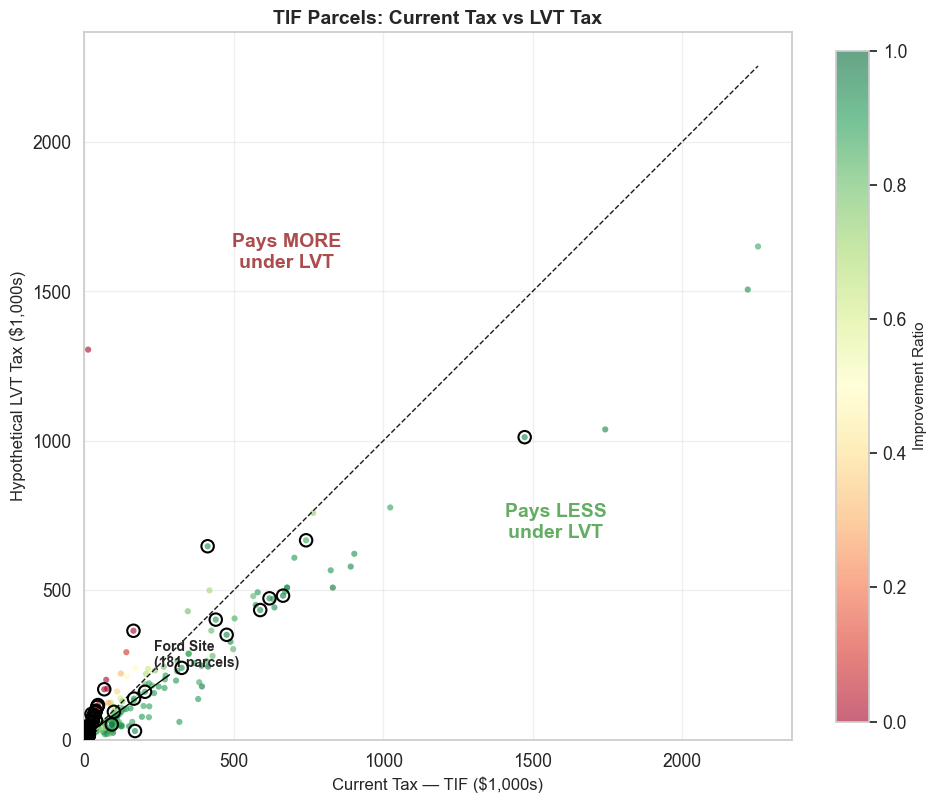

Above the line (would pay MORE under LVT): 387 parcels, $5,799,919 more
Below the line (would pay LESS under LVT): 2,154 parcels, $-14,390,351 less

Net effect if all TIF parcels moved to LVT: $-8,590,432


In [392]:
# Scatter: Current TIF tax vs hypothetical LVT tax for each TIF parcel
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

tif_scatter = tif_parcels[tif_parcels['current_tax'] > 0].copy()

fig, ax = plt.subplots(figsize=(10, 10))

# Color by IR (continuous)
norm = Normalize(vmin=0, vmax=1)
scatter = ax.scatter(
    tif_scatter['current_tax'] / 1000,
    tif_scatter['lvt_tax'] / 1000,
    c=tif_scatter['IR'],
    cmap='RdYlGn',
    norm=norm,
    alpha=0.6,
    s=20,
    edgecolors='none'
)

# Diagonal: where current = LVT
max_val = max(tif_scatter['current_tax'].max(), tif_scatter['lvt_tax'].max()) / 1000
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='Break-even line')

# Annotate regions
ax.text(max_val * 0.7, max_val * 0.3, 'Pays LESS\nunder LVT', fontsize=14,
        fontweight='bold', color='#228B22', alpha=0.7, ha='center')
ax.text(max_val * 0.3, max_val * 0.7, 'Pays MORE\nunder LVT', fontsize=14,
        fontweight='bold', color='#8B0000', alpha=0.7, ha='center')

# Annotate Ford Site cluster
ford = tif_scatter[tif_scatter['TIFDistrict'].str.contains('Ford site', case=False, na=False)]
if len(ford) > 0:
    ax.scatter(ford['current_tax'] / 1000, ford['lvt_tax'] / 1000,
               facecolors='none', edgecolors='black', s=80, linewidths=1.5, zorder=5)
    ax.annotate(f'Ford Site\n({len(ford)} parcels)',
                xy=(ford['current_tax'].median() / 1000, ford['lvt_tax'].median() / 1000),
                xytext=(ford['current_tax'].median() / 1000 + max_val * 0.1,
                        ford['lvt_tax'].median() / 1000 + max_val * 0.1),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=10, fontweight='bold')

ax.set_xlabel('Current Tax — TIF ($1,000s)', fontsize=12)
ax.set_ylabel('Hypothetical LVT Tax ($1,000s)', fontsize=12)
ax.set_title('TIF Parcels: Current Tax vs LVT Tax', fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.set_xlim(0, None)
ax.set_ylim(0, None)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label('Improvement Ratio', fontsize=11)

plt.tight_layout()
plt.show()

# Summary stats
above = tif_scatter[tif_scatter['lvt_tax'] > tif_scatter['current_tax']]
below = tif_scatter[tif_scatter['lvt_tax'] <= tif_scatter['current_tax']]
print(f"Above the line (would pay MORE under LVT): {len(above):,} parcels, ${above['lvt_change'].sum():,.0f} more")
print(f"Below the line (would pay LESS under LVT): {len(below):,} parcels, ${below['lvt_change'].sum():,.0f} less")
print(f"\nNet effect if all TIF parcels moved to LVT: ${tif_scatter['lvt_change'].sum():,.0f}")

## Step 11: Case Study — Victoria & Grand TIF vs LVT

In December 2025, the St. Paul City Council voted 5-1 to authorize a **$9.4 million TIF district** at the northeast corner of Grand Avenue and Victoria Street ([Twin Cities Pioneer Press, 12/18/2025](https://www.twincities.com/2025/12/18/st-paul-city-council-approves-9-million-tif-district-at-victoria-and-grand/)).

**The project:** Developer Ari Parritz / Afton Park Development will demolish Billy's on Grand (857 Grand Ave), Victoria Crossing East Mall, and a vacant 1890s apartment building to construct 90 rental apartments + 12,800 sq ft of retail. Site value goes from **$6.5M to $26.5M**.

**The TIF deal:**
| Component | Amount |
|---|---|
| Developer subsidy | $2,950,000 |
| Off-site affordable housing fund | $3,000,000 |
| Administrative costs | $908,000 |
| Interest | $2,600,000 |
| **Total TIF district** | **$9,400,000** |

This section asks: what would the same project look like under LVT instead of TIF?

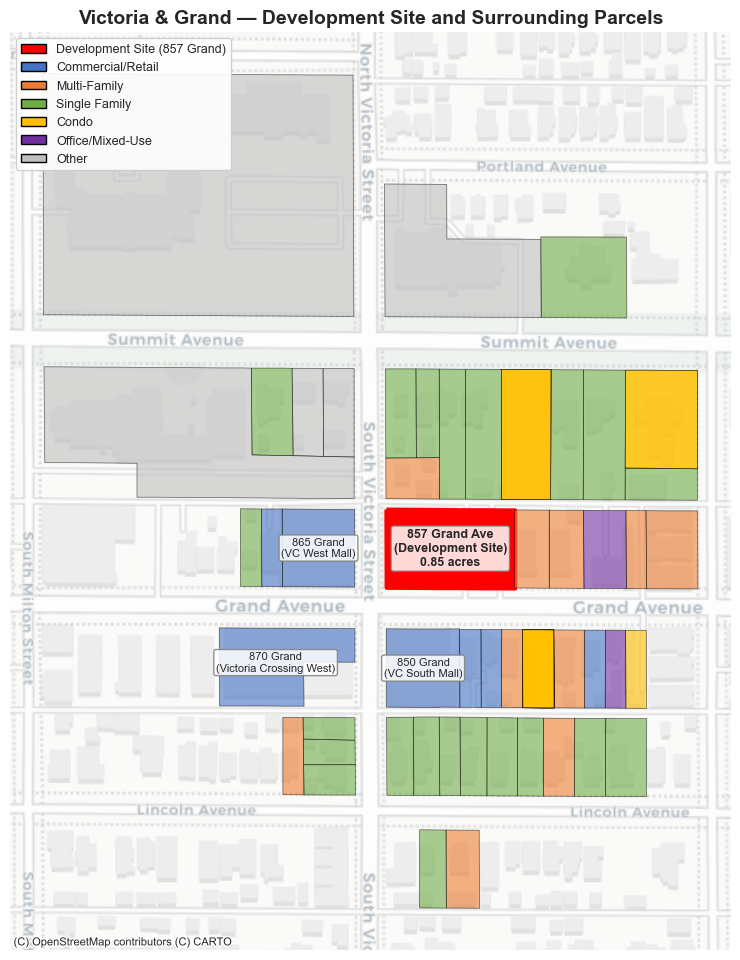

857 Grand Ave: 0.85 acres, Owner: 845 GRAND LLC, Last Sale: May 2025 for $3,552,300


In [393]:
# Map: Victoria & Grand development site and surrounding parcels
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import contextily as cx

# The development parcel: 857 Grand Ave (Billy's on Grand site, 0.85 acres)
# Owned by "845 GRAND LLC" (developer entity), purchased May 2025 for $3.55M
dev_parcel = st_paul_gdf[st_paul_gdf['SiteAddress'] == '857 GRAND AVE'].copy()

# Nearby parcels for context (~150m radius around the site)
centroid = dev_parcel.geometry.iloc[0].centroid
buffer = centroid.buffer(0.0015)  # ~150m in degrees at this latitude
nearby = st_paul_gdf[st_paul_gdf.geometry.intersects(buffer)].copy()

# Categorize nearby parcels for coloring
def classify_nearby(row):
    addr = str(row.get('SiteAddress', ''))
    if addr == '857 GRAND AVE':
        return 'Development Site (857 Grand)'
    desc = str(row.get('LandUseCodeDescription', '')).upper()
    if 'SHOPPING CENTER' in desc or 'RETAIL' in desc or 'STORE' in desc:
        return 'Commercial/Retail'
    if 'APARTMENT' in desc or 'TWO FAMILY' in desc or 'THREE FAMILY' in desc:
        return 'Multi-Family'
    if 'SINGLE FAMILY' in desc:
        return 'Single Family'
    if 'CONDO' in desc:
        return 'Condo'
    if 'OFFICE' in desc or 'MIXED' in desc:
        return 'Office/Mixed-Use'
    return 'Other'

nearby['map_category'] = nearby.apply(classify_nearby, axis=1)

# Convert to Web Mercator for contextily basemap
nearby_3857 = nearby.to_crs(epsg=3857)
dev_3857 = nearby_3857[nearby_3857['SiteAddress'] == '857 GRAND AVE']

# Color scheme
color_map = {
    'Development Site (857 Grand)': '#FF0000',
    'Commercial/Retail': '#4472C4',
    'Multi-Family': '#ED7D31',
    'Single Family': '#70AD47',
    'Condo': '#FFC000',
    'Office/Mixed-Use': '#7030A0',
    'Other': '#BFBFBF',
}

fig, ax = plt.subplots(figsize=(12, 10))

# Plot all nearby parcels by category
for cat, color in color_map.items():
    subset = nearby_3857[nearby_3857['map_category'] == cat]
    if len(subset) > 0:
        lw = 3 if cat == 'Development Site (857 Grand)' else 0.5
        ec = 'red' if cat == 'Development Site (857 Grand)' else 'black'
        alpha = 1.0 if cat == 'Development Site (857 Grand)' else 0.6
        subset.plot(ax=ax, color=color, edgecolor=ec, linewidth=lw, alpha=alpha, label=cat)

# Label key parcels on the map
labels = {
    '857 GRAND AVE': "857 Grand Ave\n(Development Site)\n0.85 acres",
    '850 GRAND AVE': '850 Grand\n(VC South Mall)',
    '865 GRAND AVE': '865 Grand\n(VC West Mall)',
    '870 GRAND AVE': '870 Grand\n(Victoria Crossing West)',
}
for addr, label in labels.items():
    parcel = nearby_3857[nearby_3857['SiteAddress'] == addr]
    if len(parcel) > 0:
        cx_pt = parcel.geometry.iloc[0].centroid.x
        cy_pt = parcel.geometry.iloc[0].centroid.y
        fontsize = 8 if addr != '857 GRAND AVE' else 9
        weight = 'bold' if addr == '857 GRAND AVE' else 'normal'
        ax.annotate(label, xy=(cx_pt, cy_pt), ha='center', va='center',
                    fontsize=fontsize, fontweight=weight,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor='gray'))

# Add basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=17)

ax.set_title('Victoria & Grand — Development Site and Surrounding Parcels',
             fontsize=14, fontweight='bold')

# Legend
legend_elements = [Patch(facecolor=c, edgecolor='black', label=cat)
                   for cat, c in color_map.items() if cat in nearby_3857['map_category'].values]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.9)

ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"857 Grand Ave: {dev_parcel.iloc[0]['ParcelAcresDeed']} acres, "
      f"Owner: {dev_parcel.iloc[0]['OwnerName']}, "
      f"Last Sale: May 2025 for ${dev_parcel.iloc[0]['SalePrice']:,.0f}")

In [394]:

# Victoria & Grand: TIF vs LVT comparison

# From the Pioneer Press article (12/18/2025):
# - Current site value: $6.5M (land + existing buildings to be demolished)
# - Projected value after development: $26.5M (90 apts + 12,800 sq ft retail)
# - The $20M difference is the new improvement value
current_site_emv = 6_500_000
projected_emv = 26_500_000
improvement_emv = projected_emv - current_site_emv  # $20M in new construction

# Estimate land/building split for the EXISTING site
# 857 Grand Ave EMV is zeroed out in our data (post-sale/demo), so we estimate
# from comparable commercial parcels on the same block:
#   850 Grand (0.49 ac): $2.72M/acre land  |  865 Grand (0.48 ac): $2.73M/acre
#   870 Grand (0.84 ac): $2.19M/acre       |  844 Grand (0.14 ac): $1.71M/acre
# Mean: ~$2.2M/acre → 0.85 acres × $2.2M = ~$1.88M land
# These are old commercial buildings (1915, 1890s) so IR ~71% is reasonable
existing_land_emv = 1_882_000     # Estimated from comparable land values per acre
existing_bldg_emv = current_site_emv - existing_land_emv  # ~$4.62M
existing_ir = existing_bldg_emv / current_site_emv  # ~71%

# TIF deal terms from the article
tif_to_developer = 2_950_000       # Direct subsidy to Afton Park Development
tif_admin = 908_000                # City administrative costs
tif_affordable_housing = 3_000_000 # Redirected to off-site affordable housing fund
tif_interest = 2_600_000           # Interest on TIF bonds
tif_total = 9_400_000              # Total TIF district cost
tif_years = 25                     # Standard MN redevelopment TIF duration
construction_years = 2             # Assumed: ~2 years to demolish + build 90-unit apt

# Minnesota Tax Capacity (TC) calculation
# MN doesn't tax EMV directly — it converts EMV to Tax Capacity using class rates:
#   - Commercial/Industrial: 1.5% on first $150K of EMV, 2.0% above $150K
#   - Apartments (4+ units): 1.25% of EMV
# This mixed-use project is ~25% retail by value, ~75% apartments (assumption
# based on 12,800 sq ft retail vs 90 apartments in the project description)
def calc_total_tc(emv, commercial_pct=0.25, apt_pct=0.75):
    comm_emv = emv * commercial_pct
    apt_emv = emv * apt_pct
    comm_tc = min(comm_emv, 150_000) * 0.015 + max(comm_emv - 150_000, 0) * 0.02
    apt_tc = apt_emv * 0.0125
    return comm_tc + apt_tc

def calc_commercial_tc(emv):
    return min(emv, 150_000) * 0.015 + max(emv - 150_000, 0) * 0.02

# THREE PHASES of the site:
#
# Phase 1: EXISTING BUILDINGS (before any development decision)
# The site has Billy's on Grand, Victoria Crossing East Mall, and a 1890s apartment.
# All are commercial properties: $6.5M total, ~71% IR
existing_tc = calc_commercial_tc(current_site_emv)
existing_tc_land = (1 - existing_ir) * existing_tc
existing_tc_imp = existing_ir * existing_tc

# Phase 2: CONSTRUCTION (buildings demolished, site vacant ~2 years)
# During demo/construction, EMV drops to land only
# Land value stays at ~$1.88M (the land didn't disappear)
demo_tc = calc_commercial_tc(existing_land_emv)
demo_ir = 0
demo_tc_land = demo_tc
demo_tc_imp = 0

# Phase 3: POST-DEVELOPMENT ($26.5M mixed-use, IR = 75.5%)
# TC calculated using blended class rates for commercial + apartment
# IR = $20M / $26.5M = 75.5%
# TC is then split by IR: land TC = (1 - IR) × total TC, imp TC = IR × total TC
post_tc = calc_total_tc(projected_emv)
post_ir = improvement_emv / projected_emv
post_tc_land = (1 - post_ir) * post_tc
post_tc_imp = post_ir * post_tc

# TAX UNDER CURRENT SYSTEM
# Tax = TC × full combined rate (city + county + school + special districts + state + RMV)
# full_tax_rate = 1.5472 per $1 of TC (calculated in Step 7 as
#   total revenue / total TC = $559,086,384 / $361,359,418)
existing_current_tax = existing_tc * full_tax_rate
demo_current_tax = demo_tc * full_tax_rate
post_current_tax = post_tc * full_tax_rate

# TAX UNDER LVT (split-rate)
# Tax = (land TC × land millage / 1000) + (imp TC × imp millage / 1000)
#
# Where do tc_land_millage (3741.0) and tc_imp_millage (935.25) come from?
# They are solved in Step 5 by model_split_rate_tax() using two constraints:
#   1. Revenue neutrality: total tax must equal current total ($559,086,384)
#   2. 4:1 ratio: land_millage = 4 × imp_millage
#
# The algebra:
#   revenue = (total_land_TC × land_mill / 1000) + (total_imp_TC × imp_mill / 1000)
#   $559,086,384 = ($78,811,352 × 4 × imp_mill / 1000) + ($282,548,066 × imp_mill / 1000)
#   $559,086,384 = imp_mill / 1000 × (4 × $78,811,352 + $282,548,066)
#   $559,086,384 = imp_mill / 1000 × $597,793,474
#   imp_mill = ($559,086,384 / $597,793,474) × 1000 = 935.25
#   land_mill = 4 × 935.25 = 3,741.00
#
# These $78.8M (land TC) and $282.5M (imp TC) come from splitting every parcel's
# TC by its improvement ratio (IR = building EMV / total EMV) across all 77,100
# city-taxable parcels. So the rates are calibrated to the entire St. Paul tax base.
existing_lvt_tax = existing_tc_land * tc_land_millage / 1000 + existing_tc_imp * tc_imp_millage / 1000
demo_lvt_tax = demo_tc_land * tc_land_millage / 1000 + demo_tc_imp * tc_imp_millage / 1000
post_lvt_tax = post_tc_land * tc_land_millage / 1000 + post_tc_imp * tc_imp_millage / 1000

print('VICTORIA & GRAND: TIF vs LVT COMPARISON')
print(f'Existing site: ${current_site_emv:,.0f} (Land: ${existing_land_emv:,.0f}, Bldg: ${existing_bldg_emv:,.0f}, IR: {existing_ir:.0%})')
print(f'Post-development: ${projected_emv:,.0f} (${improvement_emv:,.0f} in new improvements, IR: {post_ir:.1%})')
print()

print(f'{"Phase":35s} {"Current System":>15s} {"LVT (4:1)":>15s}')
print('-' * 67)
print(f'{"Existing buildings (pre-demo)":35s} ${existing_current_tax:>13,.0f} ${existing_lvt_tax:>13,.0f}')
print(f'{"Construction (land only)":35s} ${demo_current_tax:>13,.0f} ${demo_lvt_tax:>13,.0f}')
print(f'{"Post-development (built)":35s} ${post_current_tax:>13,.0f} ${post_lvt_tax:>13,.0f}')
print()
print(f'{"Tax change: existing -> built":35s} ${post_current_tax - existing_current_tax:>+13,.0f} ${post_lvt_tax - existing_lvt_tax:>+13,.0f}')

# 25-YEAR GENERAL LEVY REVENUE
# How much total tax do taxing jurisdictions receive over 25 years?
#
# CURRENT SYSTEM (no TIF): jurisdictions collect the full tax every year.
#   Years 1-2 (construction): demolition reduces EMV to land only
#   Years 3-25 (developed): full tax on $26.5M property
current_levy_total = demo_current_tax * construction_years + post_current_tax * (tif_years - construction_years)

# TIF MECHANICS (MN Statute 469.177):
# TIF captures from local NTC-based levies ONLY (city, county, school, special districts)
# The state general levy and RMV levies are NOT captured — they continue on actual value.
#
# NTC rate: 1.4406 (sum of local jurisdictions' NTC rates)
# Non-NTC component: full_tax_rate - NTC rate ≈ 0.107 per $1 of TC
#   This represents the state general levy + RMV levies (blended into TC basis)
ntc_rate = OFFICIAL_TOTAL_NTC_RATE  # 1.4406
non_ntc_rate = full_tax_rate - ntc_rate  # ~0.107 (state + RMV component)

# NTC-based portion: FROZEN at existing base for all 25 years
# The "original net tax capacity" is locked in at TIF creation
tif_ntc_frozen = existing_tc * ntc_rate * tif_years

# Non-NTC portion (state + RMV): NOT captured by TIF, continues on actual value
# During construction: assessed on land-only TC; after: on full post-development TC
tif_non_ntc = (demo_tc * non_ntc_rate * construction_years +
               post_tc * non_ntc_rate * (tif_years - construction_years))

tif_levy_total = tif_ntc_frozen + tif_non_ntc

# What NTC-based revenue WOULD have been without TIF (for measuring diversion)
no_tif_ntc = (demo_tc * ntc_rate * construction_years +
              post_tc * ntc_rate * (tif_years - construction_years))
ntc_revenue_diverted = no_tif_ntc - tif_ntc_frozen

# LVT: no TIF district, no diversion. General levy collects the full LVT tax.
#   Years 1-2 (construction): land-only TC taxed at land rate
#   Years 3-25 (developed): split-rate tax on $26.5M property
lvt_levy_total = demo_lvt_tax * construction_years + post_lvt_tax * (tif_years - construction_years)

print()
print(f'25-YEAR GENERAL LEVY REVENUE (all jurisdictions)')
print(f'  Current system (no TIF): ${current_levy_total:>12,.0f}')
print(f'  TIF scenario:            ${tif_levy_total:>12,.0f}')
print(f'  LVT scenario:            ${lvt_levy_total:>12,.0f}')
print()
print(f'  NTC revenue diverted by TIF: ${ntc_revenue_diverted:>12,.0f}')
print(f'    (State levy + RMV not captured — continues on actual value)')
print(f'  Of the TIF capture: ${tif_to_developer:,.0f} to developer, ${tif_admin:,.0f} admin, ${tif_interest:,.0f} interest')
print(f'  Plus ${tif_affordable_housing:,.0f} to off-site affordable housing fund')


VICTORIA & GRAND: TIF vs LVT COMPARISON
Existing site: $6,500,000 (Land: $1,882,000, Bldg: $4,618,000, IR: 71%)
Post-development: $26,500,000 ($20,000,000 in new improvements, IR: 75.5%)

Phase                                Current System       LVT (4:1)
-------------------------------------------------------------------
Existing buildings (pre-demo)       $      199,972 $      224,371
Construction (land only)            $       57,075 $      137,083
Post-development (built)            $      588,217 $      613,092

Tax change: existing -> built       $     +388,244 $     +388,721

25-YEAR GENERAL LEVY REVENUE (all jurisdictions)
  Current system (no TIF): $  13,643,135
  TIF scenario:            $   5,594,730
  LVT scenario:            $  14,375,290

  NTC revenue diverted by TIF: $   8,048,405
    (State levy + RMV not captured — continues on actual value)
  Of the TIF capture: $2,950,000 to developer, $908,000 admin, $2,600,000 interest
  Plus $3,000,000 to off-site affordable hous

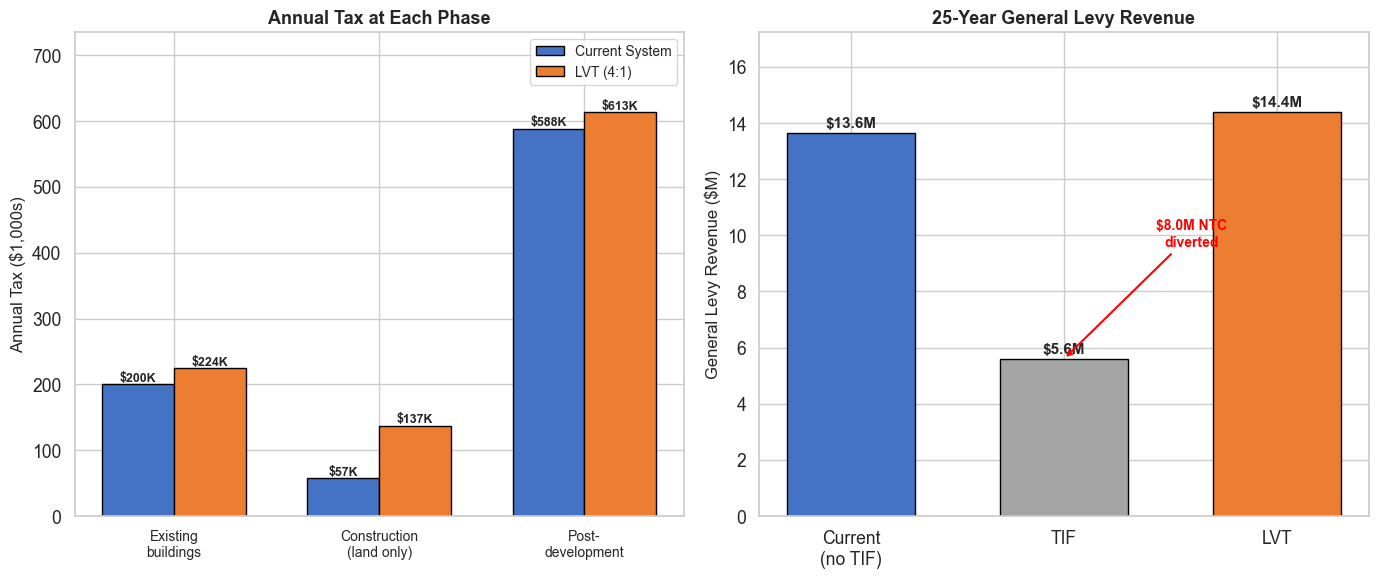

THE INCENTIVE STRUCTURE
  Existing buildings tax:  $199,972/yr (current) vs $224,371/yr (LVT)
  Post-development tax:    $588,217/yr (current) vs $613,092/yr (LVT)

  Under current system, redeveloping RAISES tax by $388,244/yr (+194%)
  Under LVT, redeveloping raises tax by $388,721/yr (+173%)
  The tax penalty for redeveloping is 1.0x HIGHER under the current system

  NTC revenue diverted by TIF over 25 years: $8.0M
  No admin costs, no interest, no political blight-finding process under LVT


In [395]:

# Incentive structure chart: three phases of the development
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left chart: side-by-side bars showing annual tax at each phase
phases = ['Existing\nbuildings', 'Construction\n(land only)', 'Post-\ndevelopment']
current_vals = [existing_current_tax / 1000, demo_current_tax / 1000, post_current_tax / 1000]
lvt_vals = [existing_lvt_tax / 1000, demo_lvt_tax / 1000, post_lvt_tax / 1000]

x = np.arange(len(phases))
width = 0.35
bars1 = ax1.bar(x - width/2, current_vals, width, label='Current System', color='#4472C4', edgecolor='black')
bars2 = ax1.bar(x + width/2, lvt_vals, width, label='LVT (4:1)', color='#ED7D31', edgecolor='black')

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'${bar.get_height():,.0f}K', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'${bar.get_height():,.0f}K', ha='center', fontsize=9, fontweight='bold')

ax1.set_ylabel('Annual Tax ($1,000s)', fontsize=12)
ax1.set_title('Annual Tax at Each Phase', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(phases, fontsize=10)
ax1.legend(fontsize=10)
ax1.set_ylim(0, max(max(current_vals), max(lvt_vals)) * 1.2)

# Right chart: 25-year revenue — NTC revenue diverted by TIF
labels = ['Current\n(no TIF)', 'TIF', 'LVT']
values = [current_levy_total / 1_000_000, tif_levy_total / 1_000_000, lvt_levy_total / 1_000_000]
colors = ['#4472C4', '#A5A5A5', '#ED7D31']

bars = ax2.bar(labels, values, color=colors, edgecolor='black', width=0.6)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'${val:,.1f}M', ha='center', fontsize=11, fontweight='bold')

# Arrow showing NTC revenue diverted by TIF
ax2.annotate(f'${ntc_revenue_diverted / 1e6:,.1f}M NTC\ndiverted',
             xy=(1, tif_levy_total / 1e6), xytext=(1.6, (current_levy_total + tif_levy_total) / 2e6),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=10, fontweight='bold', color='red', ha='center')

ax2.set_ylabel('General Levy Revenue ($M)', fontsize=12)
ax2.set_title('25-Year General Levy Revenue', fontsize=13, fontweight='bold')
ax2.set_ylim(0, max(values) * 1.2)

plt.tight_layout()
plt.show()

# Summary
print('THE INCENTIVE STRUCTURE')
print(f'  Existing buildings tax:  ${existing_current_tax:,.0f}/yr (current) vs ${existing_lvt_tax:,.0f}/yr (LVT)')
print(f'  Post-development tax:    ${post_current_tax:,.0f}/yr (current) vs ${post_lvt_tax:,.0f}/yr (LVT)')
print()
print(f'  Under current system, redeveloping RAISES tax by ${post_current_tax - existing_current_tax:,.0f}/yr (+{(post_current_tax/existing_current_tax - 1)*100:.0f}%)')
print(f'  Under LVT, redeveloping raises tax by ${post_lvt_tax - existing_lvt_tax:,.0f}/yr (+{(post_lvt_tax/existing_lvt_tax - 1)*100:.0f}%)')
print(f'  The tax penalty for redeveloping is {(post_current_tax - existing_current_tax) / (post_lvt_tax - existing_lvt_tax):.1f}x HIGHER under the current system')
print()
print(f'  NTC revenue diverted by TIF over 25 years: ${ntc_revenue_diverted / 1e6:,.1f}M')
print(f'  No admin costs, no interest, no political blight-finding process under LVT')


ST. PAUL CITY SHARE (47.9% of total tax bill)
  (Based on city levy of $416.5M out of $869.2M total local levy)

Phase                                Current System       LVT (4:1)
-------------------------------------------------------------------
Existing buildings (pre-demo)       $       95,816 $      107,506
Construction (land only)            $       27,347 $       65,683
Post-development (built)            $      281,841 $      293,760

25-YEAR CITY LEVY REVENUE
  Current system (no TIF): $   6,537,038
  TIF scenario:            $   3,592,772
  LVT scenario:            $   6,887,846
  City NTC revenue lost:   $   2,944,266  (36.6% of NTC capture)



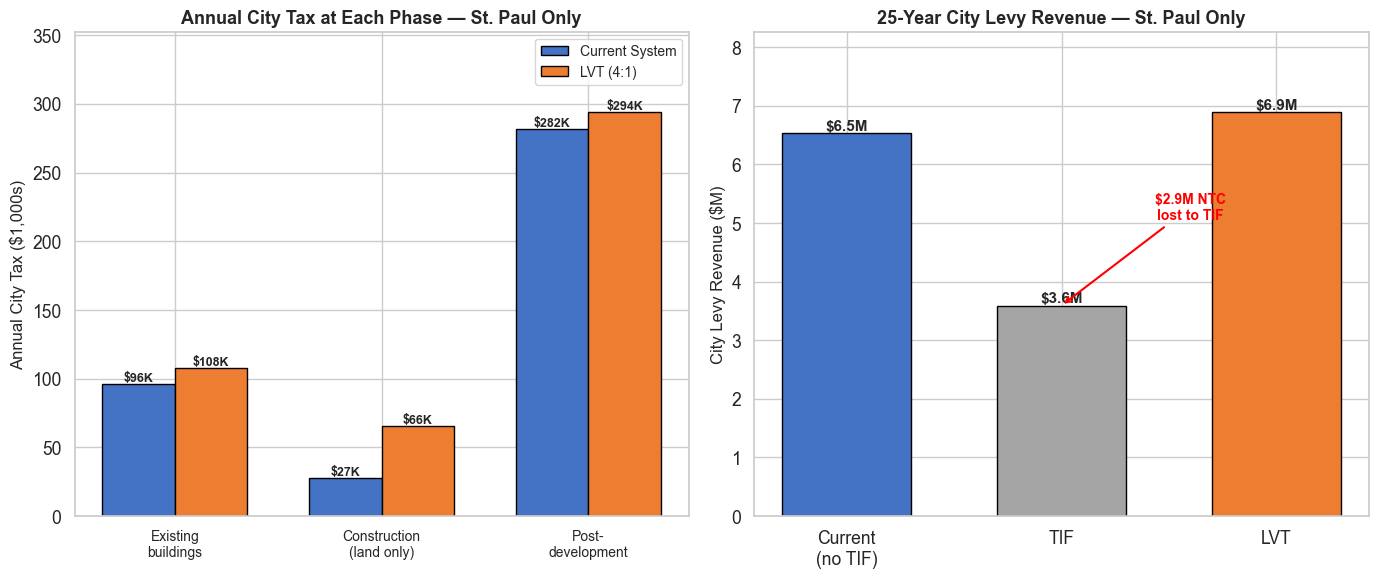

WHO BEARS THE TIF COST (NTC revenue diverted: $8,048,405)
  St. Paul city:          $ 2,944,266  (36.6% of NTC rate)
  County:                 $ 2,436,422  (30.3%)
  School district:        $ 1,926,343  (23.9%)
  Special districts:      $   741,933  (9.2%)

St. Paul approves the TIF but bears only 36.6% of the NTC cost.
The other 63.4% ($5,104,139) is borne by county, school, and special districts
  — none of which voted on this TIF.


In [396]:

# St. Paul's share of the tax impact
# From data-portal-excel.xlsx levy breakdown:
#   City NTC Levy:  $180,226,074
#   City RMV Levy:  $195,667,750
#   City FD Levy:   $40,573,652
#   City Total:     $416,467,476
#   All Local Total (excl TIF, state): $869,189,041
# City share of total bill: $416.5M / $869.2M = 47.9%
city_total_levy = 416_467_476
total_local_levy = 869_189_041
city_share_of_bill = city_total_levy / total_local_levy  # ~47.9%

# City's share of NTC rate (what TIF actually captures from)
city_share_of_ntc = OFFICIAL_CITY_TAX_RATE / OFFICIAL_TOTAL_NTC_RATE  # 36.6%

# Annual taxes — city portion (~48% of total bill)
city_existing_current = existing_current_tax * city_share_of_bill
city_demo_current = demo_current_tax * city_share_of_bill
city_post_current = post_current_tax * city_share_of_bill

city_existing_lvt = existing_lvt_tax * city_share_of_bill
city_demo_lvt = demo_lvt_tax * city_share_of_bill
city_post_lvt = post_lvt_tax * city_share_of_bill

# 25-year city levy: Current and LVT use the ~48% bill share
city_current_levy = current_levy_total * city_share_of_bill
city_lvt_levy = lvt_levy_total * city_share_of_bill

# For TIF: the city loses its share of the NTC-based capture (36.6% of NTC capture)
# but keeps its RMV and other non-NTC levies (which aren't affected by TIF)
# City TIF revenue = city share of total bill minus city's share of NTC capture
city_ntc_lost = ntc_revenue_diverted * city_share_of_ntc
city_tif_levy = city_current_levy - city_ntc_lost

print(f'ST. PAUL CITY SHARE ({city_share_of_bill:.1%} of total tax bill)')
print(f'  (Based on city levy of ${city_total_levy/1e6:,.1f}M out of ${total_local_levy/1e6:,.1f}M total local levy)')
print()
print(f'{"Phase":35s} {"Current System":>15s} {"LVT (4:1)":>15s}')
print('-' * 67)
print(f'{"Existing buildings (pre-demo)":35s} ${city_existing_current:>13,.0f} ${city_existing_lvt:>13,.0f}')
print(f'{"Construction (land only)":35s} ${city_demo_current:>13,.0f} ${city_demo_lvt:>13,.0f}')
print(f'{"Post-development (built)":35s} ${city_post_current:>13,.0f} ${city_post_lvt:>13,.0f}')
print()

print(f'25-YEAR CITY LEVY REVENUE')
print(f'  Current system (no TIF): ${city_current_levy:>12,.0f}')
print(f'  TIF scenario:            ${city_tif_levy:>12,.0f}')
print(f'  LVT scenario:            ${city_lvt_levy:>12,.0f}')
print(f'  City NTC revenue lost:   ${city_ntc_lost:>12,.0f}  (36.6% of NTC capture)')
print()

# Bar charts — St. Paul city share only
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: annual tax by phase (city share)
phases = ['Existing\nbuildings', 'Construction\n(land only)', 'Post-\ndevelopment']
current_vals = [city_existing_current / 1000, city_demo_current / 1000, city_post_current / 1000]
lvt_vals = [city_existing_lvt / 1000, city_demo_lvt / 1000, city_post_lvt / 1000]

x = np.arange(len(phases))
width = 0.35
bars1 = ax1.bar(x - width/2, current_vals, width, label='Current System', color='#4472C4', edgecolor='black')
bars2 = ax1.bar(x + width/2, lvt_vals, width, label='LVT (4:1)', color='#ED7D31', edgecolor='black')

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'${bar.get_height():,.0f}K', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'${bar.get_height():,.0f}K', ha='center', fontsize=9, fontweight='bold')

ax1.set_ylabel('Annual City Tax ($1,000s)', fontsize=12)
ax1.set_title('Annual City Tax at Each Phase — St. Paul Only', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(phases, fontsize=10)
ax1.legend(fontsize=10)
ax1.set_ylim(0, max(max(current_vals), max(lvt_vals)) * 1.2)

# Right: 25-year city levy revenue
labels = ['Current\n(no TIF)', 'TIF', 'LVT']
values = [city_current_levy / 1_000_000, city_tif_levy / 1_000_000, city_lvt_levy / 1_000_000]
colors = ['#4472C4', '#A5A5A5', '#ED7D31']

bars = ax2.bar(labels, values, color=colors, edgecolor='black', width=0.6)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'${val:,.1f}M', ha='center', fontsize=11, fontweight='bold')

ax2.annotate(f'${city_ntc_lost / 1e6:,.1f}M NTC\nlost to TIF',
             xy=(1, city_tif_levy / 1e6), xytext=(1.6, (city_current_levy + city_tif_levy) / 2e6),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=10, fontweight='bold', color='red', ha='center')

ax2.set_ylabel('City Levy Revenue ($M)', fontsize=12)
ax2.set_title('25-Year City Levy Revenue — St. Paul Only', fontsize=13, fontweight='bold')
ax2.set_ylim(0, max(values) * 1.2)

plt.tight_layout()
plt.show()

# Cost sharing breakdown
other_ntc_lost = ntc_revenue_diverted * (1 - city_share_of_ntc)
print(f'WHO BEARS THE TIF COST (NTC revenue diverted: ${ntc_revenue_diverted:,.0f})')
print(f'  St. Paul city:          ${city_ntc_lost:>10,.0f}  ({city_share_of_ntc:.1%} of NTC rate)')
print(f'  County:                 ${ntc_revenue_diverted * 0.4361 / OFFICIAL_TOTAL_NTC_RATE:>10,.0f}  (30.3%)')
print(f'  School district:        ${ntc_revenue_diverted * 0.3448 / OFFICIAL_TOTAL_NTC_RATE:>10,.0f}  (23.9%)')
print(f'  Special districts:      ${ntc_revenue_diverted * 0.1328 / OFFICIAL_TOTAL_NTC_RATE:>10,.0f}  (9.2%)')
print()
print(f'St. Paul approves the TIF but bears only {city_share_of_ntc:.1%} of the NTC cost.')
print(f'The other {1 - city_share_of_ntc:.1%} (${other_ntc_lost:,.0f}) is borne by county, school, and special districts')
print(f'  — none of which voted on this TIF.')



# Step 12: Ford Site / Highland Bridge — TIF vs LVT

The Ford Site is the largest active TIF district in St. Paul: **122 acres** of the former Ford Motor Company assembly plant in Highland Park, being redeveloped into a mixed-use neighborhood called "Highland Bridge" by Ryan Companies.

**Three TIF districts** cover the site:

| District | Type | Certified | Original NTC | Current NTC | Captured NTC | Annual TIF Revenue | Expires |
|---|---|---|---|---|---|---|---|
| #322 | Redevelopment | 5/28/2016 | $479,333 | $4,444,201 | $3,714,678 | $4,867,764 | 12/31/2047 |
| #345 Housing #1 | Housing | 8/17/2021 | $29,440 | $755,155 | $725,715 | $985,581 | 12/31/2049 |
| #346 Housing #2 | Housing | 8/17/2021 | $17,504 | $534,280 | $516,776 | $698,074 | 12/31/2049 |
| **Combined** | | | **$526,277** | **$5,733,636** | **$4,957,169** | **$6,551,419** | |

*Source: [St. Paul HRA Annual TIF Disclosure, 2024](https://www.stpaul.gov/sites/default/files/2025-08/St%20Paul%20Annual%20TIF%20Disclosure%202024%20Report%20Year.pdf)*

**Public subsidy**: ~$53M infrastructure TIF + ~$46.9M affordable housing TIF = **~$100M total**

**Key facts**:
- Ford closed the plant in 2011; demolished 2012-2014
- Ryan Companies purchased 122 acres for $61M (December 2019)
- Plan: ~3,140 housing units + 265K sf office + 150K sf retail
- Currently ~50% developed; rent control stalled market-rate construction 2022-2024
- **86.5% of current tax capacity is captured** by TIF — general levy gets only the frozen base


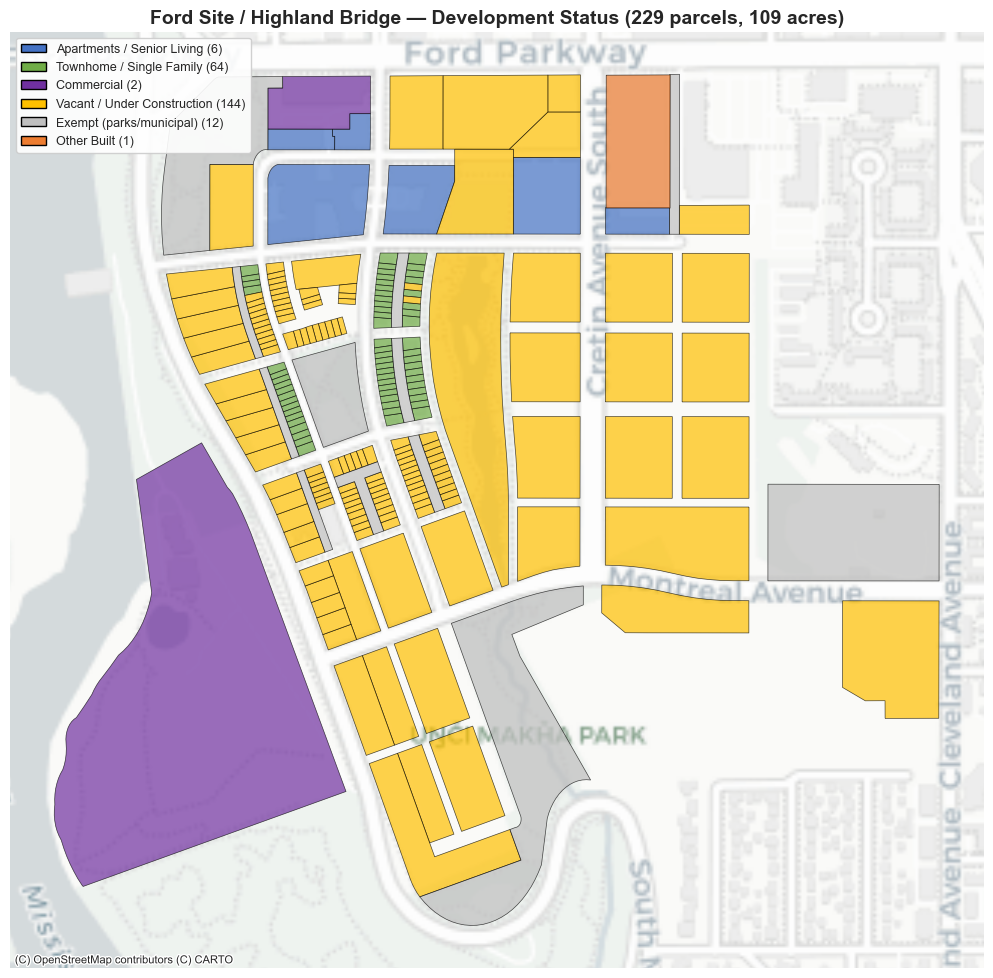

Apartments / Senior Living             6 parcels     6.5 acres  $  128,591,300 EMV
Townhome / Single Family              64 parcels     2.4 acres  $   36,760,000 EMV
Commercial                             2 parcels    23.1 acres  $   15,918,100 EMV
Vacant / Under Construction          144 parcels    55.6 acres  $  169,632,600 EMV
Exempt (parks/municipal)              12 parcels    19.1 acres  $    2,573,800 EMV
Other Built                            1 parcels     2.6 acres  $   70,000,000 EMV


In [397]:

# Map: Ford Site parcels colored by development status
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import contextily as cx

ford_parcels = st_paul_gdf[st_paul_gdf['TIFDistrict'].str.contains('Ford', case=False, na=False)].copy()

# Classify by development status
def classify_ford(row):
    if row.get('TaxExemptYN') == 'Y':
        return 'Exempt (parks/municipal)'
    desc = str(row.get('LandUseCodeDescription', '')).upper()
    if 'VACANT' in desc or 'OUTLOT' in desc:
        return 'Vacant / Under Construction'
    if row.get('EMVBuilding1', 0) == 0:
        return 'Vacant / Under Construction'
    if 'TOWNHOME' in desc or 'SINGLE FAMILY' in desc:
        return 'Townhome / Single Family'
    if 'APARTMENT' in desc or 'ASSISTED' in desc:
        return 'Apartments / Senior Living'
    if 'COMMERCIAL' in desc or 'OFFICE' in desc or 'MEDICAL' in desc or 'WAREHOUSE' in desc:
        return 'Commercial'
    return 'Other Built'

ford_parcels['dev_status'] = ford_parcels.apply(classify_ford, axis=1)
ford_3857 = ford_parcels.to_crs(epsg=3857)

color_map = {
    'Apartments / Senior Living': '#4472C4',
    'Townhome / Single Family': '#70AD47',
    'Commercial': '#7030A0',
    'Vacant / Under Construction': '#FFC000',
    'Exempt (parks/municipal)': '#BFBFBF',
    'Other Built': '#ED7D31',
}

fig, ax = plt.subplots(figsize=(14, 10))

for cat, color in color_map.items():
    subset = ford_3857[ford_3857['dev_status'] == cat]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor='black', linewidth=0.5, alpha=0.7, label=cat)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=15)

ax.set_title('Ford Site / Highland Bridge — Development Status (229 parcels, 109 acres)',
             fontsize=14, fontweight='bold')

legend_elements = [Patch(facecolor=c, edgecolor='black', label=f'{cat} ({len(ford_3857[ford_3857["dev_status"]==cat])})')
                   for cat, c in color_map.items() if cat in ford_3857['dev_status'].values]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Summary counts
for status in color_map:
    sub = ford_parcels[ford_parcels['dev_status'] == status]
    if len(sub) > 0:
        print(f"{status:35s} {len(sub):>4} parcels  {sub['ParcelAcresDeed'].sum():>6.1f} acres  ${sub['EMVTotal1'].sum():>13,.0f} EMV")


In [398]:

# Ford Site: TIF vs LVT analysis

# Official TIF data from St. Paul HRA Annual Disclosure (2024)
# Source: https://www.stpaul.gov/sites/default/files/2025-08/St%20Paul%20Annual%20TIF%20Disclosure%202024%20Report%20Year.pdf
# Three TIF districts cover the Ford Site:
#   - #322 (Redevelopment): main infrastructure TIF, certified 2016, $53M authorized
#   - #345 (Housing #1): affordable housing (Emma Norton, Nellie Francis), certified 2021
#   - #346 (Housing #2): affordable housing (CommonBond senior), certified 2021
ford_tif = {
    '322 (Redevelopment)': {
        'certified': '5/28/2016', 'original_ntc': 479_333, 'current_ntc': 4_444_201,
        'captured_ntc': 3_714_678, 'annual_tif_revenue': 4_867_764,
        'expires': '12/31/2047', 'first_increment': '6/2020',
    },
    '345 (Housing #1)': {
        'certified': '8/17/2021', 'original_ntc': 29_440, 'current_ntc': 755_155,
        'captured_ntc': 725_715, 'annual_tif_revenue': 985_581,
        'expires': '12/31/2049', 'first_increment': '7/2024',
    },
    '346 (Housing #2)': {
        'certified': '8/17/2021', 'original_ntc': 17_504, 'current_ntc': 534_280,
        'captured_ntc': 516_776, 'annual_tif_revenue': 698_074,
        'expires': '12/31/2049', 'first_increment': '7/2024',
    },
}

# Combine across all three districts
# Original NTC = the tax capacity when TIF was certified (the "frozen base")
#   This is what jurisdictions continue to receive taxes on
# Captured NTC = current NTC minus original NTC (the "increment")
#   This is what gets diverted to the TIF authority
# Annual TIF revenue = taxes generated by the captured NTC (diverted away from jurisdictions)
total_original_ntc = sum(d['original_ntc'] for d in ford_tif.values())   # $526,277
total_current_ntc = sum(d['current_ntc'] for d in ford_tif.values())     # $5,733,636
total_captured_ntc = sum(d['captured_ntc'] for d in ford_tif.values())   # $4,957,169
total_annual_tif = sum(d['annual_tif_revenue'] for d in ford_tif.values())  # $6,551,419
pct_captured = total_captured_ntc / total_current_ntc * 100  # 86.5% — almost all value is captured

# From our parcel data: calculate what each Ford parcel would pay under LVT
# Same approach as the citywide model in Step 5:
#   1. Split each parcel's TaxCapacity by improvement ratio (IR = building EMV / total EMV)
#   2. Apply split-rate millages: land TC × 3741/1000 + imp TC × 935.25/1000
# These millages come from the full-bill model calibrated to all 77,100 city-taxable parcels
ford_taxable = ford_parcels[(ford_parcels['TaxExemptYN'] != 'Y') & (ford_parcels['TaxCapacity'] > 0)].copy()
ford_taxable['IR'] = np.where(ford_taxable['EMVTotal1'] > 0,
                               ford_taxable['EMVBuilding1'] / ford_taxable['EMVTotal1'], 0)
ford_taxable['TC_Land'] = (1 - ford_taxable['IR']) * ford_taxable['TaxCapacity']
ford_taxable['TC_Imp'] = ford_taxable['IR'] * ford_taxable['TaxCapacity']
ford_taxable['lvt_tax'] = (ford_taxable['TC_Land'] * tc_land_millage / 1000 +
                           ford_taxable['TC_Imp'] * tc_imp_millage / 1000)
ford_taxable['lvt_change'] = ford_taxable['lvt_tax'] - ford_taxable['TotalTax1']

# Split by development status (classified in the map cell above)
# Built = apartments, townhomes, commercial (high IR → pay less under LVT)
# Vacant = undeveloped land (IR=0 → all TC taxed at high land rate → pay more under LVT)
ford_built = ford_taxable[ford_taxable['dev_status'].isin(['Apartments / Senior Living',
    'Townhome / Single Family', 'Commercial', 'Other Built'])]
ford_vacant = ford_taxable[ford_taxable['dev_status'] == 'Vacant / Under Construction']

print('FORD SITE / HIGHLAND BRIDGE: TIF vs LVT')
print(f'229 parcels, 109 acres, 3 TIF districts')
print()

print('OFFICIAL TIF DATA (2024 Disclosure)')
print(f'  Original NTC (frozen base):   ${total_original_ntc:>12,.0f}')
print(f'  Current NTC:                  ${total_current_ntc:>12,.0f}')
print(f'  Captured NTC (increment):     ${total_captured_ntc:>12,.0f}  ({pct_captured:.1f}% captured)')
print(f'  Annual TIF revenue diverted:  ${total_annual_tif:>12,.0f}')
print()

# What jurisdictions actually receive from the Ford Site under TIF:
# Only the frozen base × NTC rate. The increment is diverted.
# NTC rate = 1.4406 (sum of city + county + school + special district rates)
# Note: state general levy and RMV levies are NOT captured by TIF
general_levy_from_ford = total_original_ntc * OFFICIAL_TOTAL_NTC_RATE
print(f'ANNUAL GENERAL LEVY FROM FORD SITE')
print(f'  Under TIF (frozen base only):  ${general_levy_from_ford:>10,.0f}/yr')
print(f'  Under LVT (no TIF):            ${ford_taxable["lvt_tax"].sum():>10,.0f}/yr')
print(f'  Current TotalTax1:              ${ford_taxable["TotalTax1"].sum():>10,.0f}/yr')
print(f'    (but ${total_annual_tif:,.0f} of that is captured by TIF)')
print()

# How LVT shifts the burden between built and vacant parcels:
# Built parcels have high IR (median ~72%) so more of their TC is taxed at the lower
# improvement rate (935.25) → they pay less
# Vacant parcels have IR=0 so all their TC is taxed at the high land rate (3741) → they pay more
# This is the LVT incentive: penalize holding undeveloped land, reward building
print('LVT IMPACT BY DEVELOPMENT STATUS')
print(f'  {"Status":35s} {"Current":>12s} {"LVT":>12s} {"Change":>12s}  {"Med IR"}')
print(f'  {"-"*85}')
for status, label in [('Built', ford_built), ('Vacant', ford_vacant)]:
    sub = label
    if len(sub) > 0:
        print(f'  {status + " (" + str(len(sub)) + " parcels)":35s} '
              f'${sub["TotalTax1"].sum():>11,.0f} ${sub["lvt_tax"].sum():>11,.0f} '
              f'${sub["lvt_change"].sum():>+11,.0f}  {sub["IR"].median()*100:.0f}%')

print()
print(f'  Built parcels (high IR) would pay LESS under LVT')
print(f'  Vacant parcels (IR=0) would pay {ford_vacant["lvt_tax"].sum() / ford_vacant["TotalTax1"].sum():.1f}x MORE under LVT')
print(f'  This creates a strong incentive to develop the remaining 48 acres of vacant land')

# Remaining TIF duration and total future diversion
# District 322 expires 12/31/2047 → 21 years from 2026
# Districts 345/346 expire 12/31/2049 → 23 years from 2026
# Weighted average: ~22 years remaining
remaining_years = 22

# Annual NTC-based revenue diverted = captured NTC × total NTC rate
# This is what local jurisdictions lose each year to TIF
# (State levy and RMV are not captured, per MN Statute 469.177)
annual_ntc_diverted = total_captured_ntc * OFFICIAL_TOTAL_NTC_RATE
total_future_diversion = annual_ntc_diverted * remaining_years

# Under LVT, all tax revenue flows to the general levy (no TIF diversion)
lvt_annual = ford_taxable['lvt_tax'].sum()
lvt_total = lvt_annual * remaining_years

print()
print(f'PROJECTED REVENUE OVER REMAINING {remaining_years} YEARS (at current development level)')
print(f'  TIF: general levy receives frozen base only')
print(f'    ${general_levy_from_ford:,.0f}/yr × {remaining_years} years = ${general_levy_from_ford * remaining_years:>12,.0f}')
print(f'  LVT: full split-rate tax flows to general levy')
print(f'    ${lvt_annual:,.0f}/yr × {remaining_years} years = ${lvt_total:>12,.0f}')
print(f'  NTC revenue diverted by TIF over {remaining_years} years: ${total_future_diversion:>12,.0f}')
print()

# At full buildout: the site is projected to generate $22.3M/yr in property taxes
# (Source: St. Paul city documents / Highland Bridge FAQ)
# But under TIF, the general levy STILL only gets the frozen base ($758K/yr)
# The gap between full tax and frozen base grows as more buildings are completed
projected_full_tax = 22_300_000
print(f'AT FULL BUILDOUT (projected ${projected_full_tax/1e6:.1f}M/yr annual tax)')
print(f'  Under TIF: general levy still gets only ${general_levy_from_ford:,.0f}/yr (frozen base)')
print(f'  The gap between full tax and frozen base grows as development completes')
print(f'  At full buildout, TIF would capture ${projected_full_tax - general_levy_from_ford:,.0f}/yr')


FORD SITE / HIGHLAND BRIDGE: TIF vs LVT
229 parcels, 109 acres, 3 TIF districts

OFFICIAL TIF DATA (2024 Disclosure)
  Original NTC (frozen base):   $     526,277
  Current NTC:                  $   5,733,636
  Captured NTC (increment):     $   4,957,169  (86.5% captured)
  Annual TIF revenue diverted:  $   6,551,419

ANNUAL GENERAL LEVY FROM FORD SITE
  Under TIF (frozen base only):  $   758,155/yr
  Under LVT (no TIF):            $10,300,681/yr
  Current TotalTax1:              $ 8,400,530/yr
    (but $6,551,419 of that is captured by TIF)

LVT IMPACT BY DEVELOPMENT STATUS
  Status                                   Current          LVT       Change  Med IR
  -------------------------------------------------------------------------------------
  Built (73 parcels)                  $  4,965,980 $  4,485,690 $   -480,291  71%
  Vacant (144 parcels)                $  3,434,550 $  5,814,992 $ +2,005,200  0%

  Built parcels (high IR) would pay LESS under LVT
  Vacant parcels (IR=0) would 

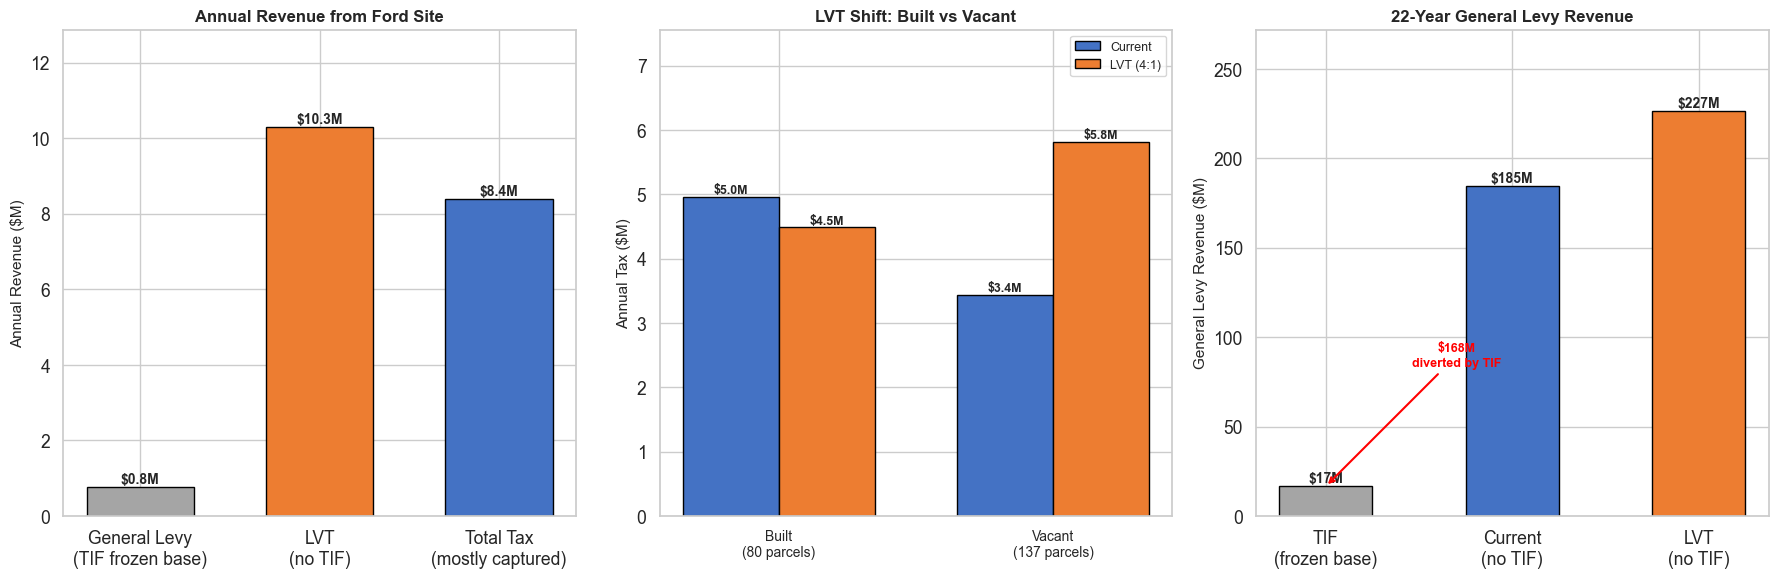

WHO BEARS THE FORD SITE TIF COST
  Annual NTC diverted: $7,141,298
  Over 22 years:       $157,108,549

  Jurisdiction                    Annual      22-Year Share
  -----------------------------------------------------------------
  St. Paul city             $  2,612,428 $ 57,473,417  36.6%
  Ramsey County             $  2,161,821 $ 47,560,071  30.3%
  School District 625       $  1,709,232 $ 37,603,101  23.9%
  Special districts         $    658,312 $ 14,482,865  9.2%

22-YEAR COMPARISON (at current development level)
  TIF (frozen base):     $  16,679,402
  Current (no TIF):      $ 184,811,665
  LVT (no TIF):          $ 226,614,986
  TIF diverts vs current: $ 168,132,263
  LVT vs TIF:            $+209,935,584

  The Ford Site TIF diverts $157M from the general levy over 22 years
  St. Paul approved the TIF but bears only 36.6% of the NTC cost
  Under LVT, all $227M would flow to the general levy — no subsidy needed
  And the 144 vacant parcels would face 1.7x higher taxes,
  acceler

In [399]:

# Ford Site charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1: Current annual revenue — what the general levy actually receives
# Under TIF: only the frozen base ($526K NTC × 1.4406 rate = $758K/yr)
# Under LVT: full split-rate tax on all Ford parcels ($10.4M/yr)
# Total tax: $8.4M/yr is generated, but $6.6M of that is captured by TIF
ax1 = axes[0]
labels = ['General Levy\n(TIF frozen base)', 'LVT\n(no TIF)', 'Total Tax\n(mostly captured)']
values = [general_levy_from_ford / 1e6, lvt_annual / 1e6, ford_taxable['TotalTax1'].sum() / 1e6]
colors = ['#A5A5A5', '#ED7D31', '#4472C4']
bars = ax1.bar(labels, values, color=colors, edgecolor='black', width=0.6)
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'${val:,.1f}M', ha='center', fontsize=10, fontweight='bold')
ax1.set_ylabel('Annual Revenue ($M)', fontsize=11)
ax1.set_title('Annual Revenue from Ford Site', fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(values) * 1.25)

# Chart 2: LVT shifts tax from built to vacant parcels
# Built parcels (apartments, townhomes) have high IR → taxed more at lower imp rate → pay less
# Vacant parcels have IR=0 → all TC taxed at high land rate → pay much more
# This is the development incentive: holding vacant land becomes expensive
ax2 = axes[1]
categories = ['Built\n(80 parcels)', 'Vacant\n(137 parcels)']
current_vals = [ford_built['TotalTax1'].sum() / 1e6, ford_vacant['TotalTax1'].sum() / 1e6]
lvt_vals_chart = [ford_built['lvt_tax'].sum() / 1e6, ford_vacant['lvt_tax'].sum() / 1e6]

x = np.arange(len(categories))
width = 0.35
b1 = ax2.bar(x - width/2, current_vals, width, label='Current', color='#4472C4', edgecolor='black')
b2 = ax2.bar(x + width/2, lvt_vals_chart, width, label='LVT (4:1)', color='#ED7D31', edgecolor='black')
for bar in b1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'${bar.get_height():,.1f}M', ha='center', fontsize=9, fontweight='bold')
for bar in b2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'${bar.get_height():,.1f}M', ha='center', fontsize=9, fontweight='bold')
ax2.set_ylabel('Annual Tax ($M)', fontsize=11)
ax2.set_title('LVT Shift: Built vs Vacant', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(categories, fontsize=10)
ax2.legend(fontsize=9)
ax2.set_ylim(0, max(max(current_vals), max(lvt_vals_chart)) * 1.3)

# Chart 3: 22-year projected general levy revenue (remaining TIF duration)
# TIF: frozen base × NTC rate × 22 years ≈ $16.7M total to general levy
# LVT: full split-rate tax × 22 years ≈ $228M total to general levy
# Current system (no TIF): full_tax_rate × TC × 22 years
# This uses current development level — at full buildout the gap would be even larger
ax3 = axes[2]

# Add current system (no TIF) for comparison
# This is what jurisdictions would receive if Ford parcels were NOT in a TIF district
# and were taxed at the current flat rate (full_tax_rate)
current_system_annual = ford_taxable['TotalTax1'].sum()
current_system_total = current_system_annual * remaining_years

labels3 = ['TIF\n(frozen base)', 'Current\n(no TIF)', 'LVT\n(no TIF)']
vals3 = [general_levy_from_ford * remaining_years / 1e6,
         current_system_total / 1e6,
         lvt_total / 1e6]
colors3 = ['#A5A5A5', '#4472C4', '#ED7D31']
bars3 = ax3.bar(labels3, vals3, color=colors3, edgecolor='black', width=0.5)
for bar, val in zip(bars3, vals3):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'${val:,.0f}M', ha='center', fontsize=10, fontweight='bold')

ax3.annotate(f'${(current_system_total - general_levy_from_ford * remaining_years) / 1e6:,.0f}M\ndiverted by TIF',
             xy=(0, vals3[0]), xytext=(0.7, vals3[0] + (vals3[1] - vals3[0]) * 0.4),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=9, fontweight='bold', color='red', ha='center')

ax3.set_ylabel('General Levy Revenue ($M)', fontsize=11)
ax3.set_title(f'{remaining_years}-Year General Levy Revenue', fontsize=12, fontweight='bold')
ax3.set_ylim(0, max(vals3) * 1.2)

plt.tight_layout()
plt.show()

# City share breakdown: who loses revenue from the Ford Site TIF?
# TIF captures from local NTC-based levies (city, county, school, special districts)
# Each jurisdiction's share = their NTC rate / total NTC rate
# City: 0.5270 / 1.4406 = 36.6%
# County: 0.4361 / 1.4406 = 30.3%
# School: 0.3448 / 1.4406 = 23.9%
# Special: 0.1328 / 1.4406 = 9.2%
city_share_of_ntc = OFFICIAL_CITY_TAX_RATE / OFFICIAL_TOTAL_NTC_RATE
city_annual_ntc_lost = annual_ntc_diverted * city_share_of_ntc
city_total_lost = city_annual_ntc_lost * remaining_years

print(f'WHO BEARS THE FORD SITE TIF COST')
print(f'  Annual NTC diverted: ${annual_ntc_diverted:,.0f}')
print(f'  Over {remaining_years} years:       ${total_future_diversion:,.0f}')
print()
print(f'  {"Jurisdiction":25s} {"Annual":>12s} {str(remaining_years) + "-Year":>12s} {"Share"}')
print(f'  {"-"*65}')
for name, rate in [('St. Paul city', 0.5270), ('Ramsey County', 0.4361),
                    ('School District 625', 0.3448), ('Special districts', 0.1328)]:
    share = rate / OFFICIAL_TOTAL_NTC_RATE
    annual = annual_ntc_diverted * share
    total = annual * remaining_years
    print(f'  {name:25s} ${annual:>11,.0f} ${total:>11,.0f}  {share:.1%}')
print()

# Compare all three scenarios over 22 years
print(f'{remaining_years}-YEAR COMPARISON (at current development level)')
print(f'  TIF (frozen base):     ${general_levy_from_ford * remaining_years:>12,.0f}')
print(f'  Current (no TIF):      ${current_system_total:>12,.0f}')
print(f'  LVT (no TIF):          ${lvt_total:>12,.0f}')
print(f'  TIF diverts vs current: ${current_system_total - general_levy_from_ford * remaining_years:>12,.0f}')
print(f'  LVT vs TIF:            ${lvt_total - general_levy_from_ford * remaining_years:>+12,.0f}')
print()
print(f'  The Ford Site TIF diverts ${total_future_diversion/1e6:,.0f}M from the general levy over {remaining_years} years')
print(f'  St. Paul approved the TIF but bears only {city_share_of_ntc:.1%} of the NTC cost')
print(f'  Under LVT, all ${lvt_total/1e6:,.0f}M would flow to the general levy — no subsidy needed')
print(f'  And the {len(ford_vacant)} vacant parcels would face {ford_vacant["lvt_tax"].sum() / ford_vacant["TotalTax1"].sum():.1f}x higher taxes,')
print(f'  accelerating development without $100M in public subsidy')
